In [1]:
import numpy as np
import pandas as pd
import plotly.express as px
import streamlit as st

In [2]:
df = pd.read_csv(r'C:\Users\Dell\OneDrive\Desktop\George project\Sales - Marketing customer dataset.csv')

In [3]:
df

,customer_id,gender,age,country,city,signup_date,last_purchase_date,acquisition_channel,device_type,subscription_type,...,support_tickets,refund_requested,delivery_delay_days,payment_method,satisfaction_score,nps_score,marketing_spend_per_user,lifetime_value,last_3_month_purchase_freq,churn
0,10001,Male,52.0,India,Berlin,2022-05-10 00:00:00,2024-12-31 00:00:00,Email,Tablet,Annual,...,0,0,3,UPI,3.0,10,27.56,915.310827,14,0
1,10002,NaN,35.0,Germany,Mumbai,2024-06-16 00:00:00,2024-05-07 00:00:00,Organic,Desktop,Monthly,...,5,0,3,BKash,3.0,7,15.15,2079.960938,11,0
2,10003,Female,27.0,Germany,London,2023-08-23 00:00:00,2024-04-28 00:00:00,Email,Mobile,Annual,...,1,0,2,UPI,5.0,6,13.51,1379.150885,9,0
3,10004,Female,36.0,India,Mumbai,2024-01-28 00:00:00,2023-05-20 00:00:00,Facebook Ads,Tablet,Annual,...,0,0,2,PayPal,4.0,6,25.65,774.652684,7,0
4,10005,Male,29.0,USA,Hamburg,2023-07-21 00:00:00,2024-04-07 00:00:00,Referral,Mobile,Monthly,...,2,1,4,BKash,3.0,1,12.39,87.680409,11,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14995,24996,Female,24.0,UK,New York,2023-10-23 00:00:00,2024-03-02 00:00:00,Referral,Desktop,Monthly,...,3,0,3,UPI,4.0,2,16.96,796.486833,9,0
14996,24997,Male,26.0,Bangladesh,London,2023-01-20 00:00:00,2024-12-03 00:00:00,Google Ads,Mobile,Monthly,...,3,0,2,BKash,NaN,6,23.86,2155.987233,0,0
14997,24998,Male,42.0,USA,Dhaka,2022-10-11 00:00:00,2023-12-04 00:00:00,Organic,Desktop,Monthly,...,3,0,5,UPI,4.0,4,12.55,614.326226,14,0
14998,24999,Female,31.0,UK,Dhaka,2022-04-01 00:00:00,2024-11-11 00:00:00,Facebook Ads,Desktop,Monthly,...,5,1,1,UPI,3.0,1,19.03,849.936622,8,1


In [4]:
df.shape

(15000, 30)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 30 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   customer_id                 15000 non-null  int64  
 1   gender                      14262 non-null  object 
 2   age                         13800 non-null  float64
 3   country                     15000 non-null  object 
 4   city                        15000 non-null  object 
 5   signup_date                 15000 non-null  object 
 6   last_purchase_date          15000 non-null  object 
 7   acquisition_channel         15000 non-null  object 
 8   device_type                 15000 non-null  object 
 9   subscription_type           15000 non-null  object 
 10  is_premium_user             15000 non-null  int64  
 11  total_visits                15000 non-null  int64  
 12  avg_session_time            15000 non-null  float64
 13  pages_per_session           150

In [6]:
df.drop(columns=['customer_id', 'coupon_code', 'city' ], inplace=True)
df.shape

(15000, 27)

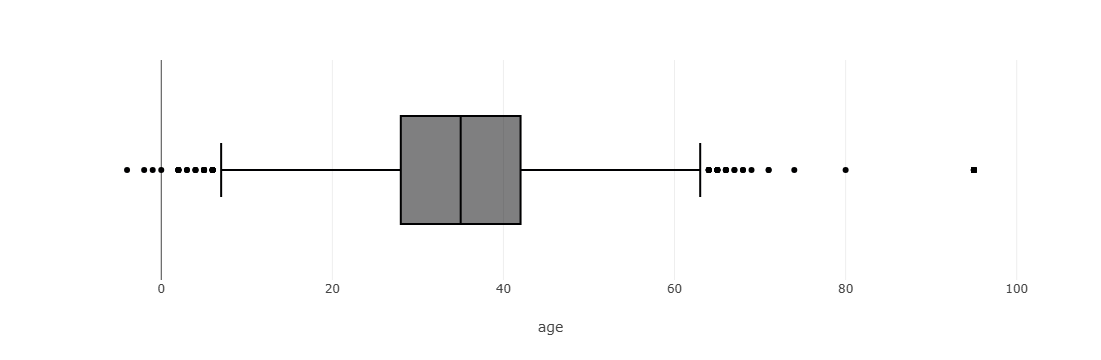

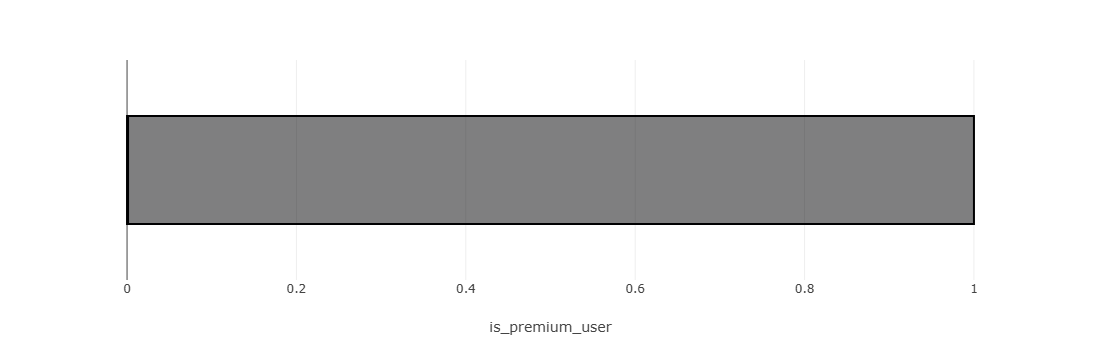

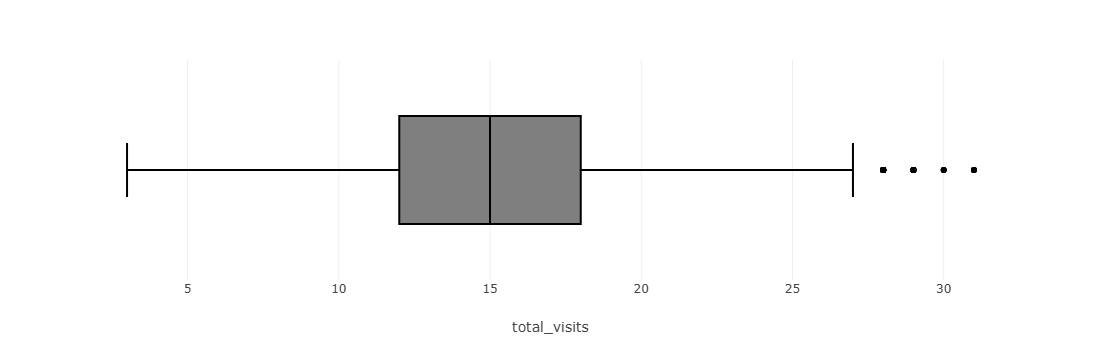

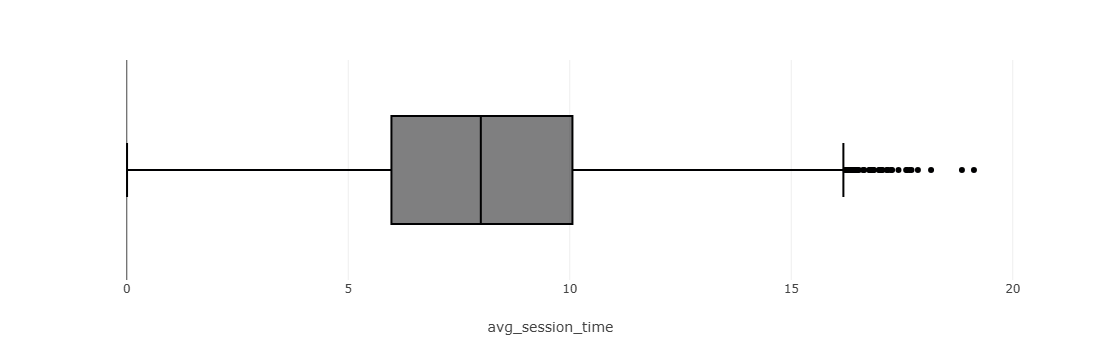

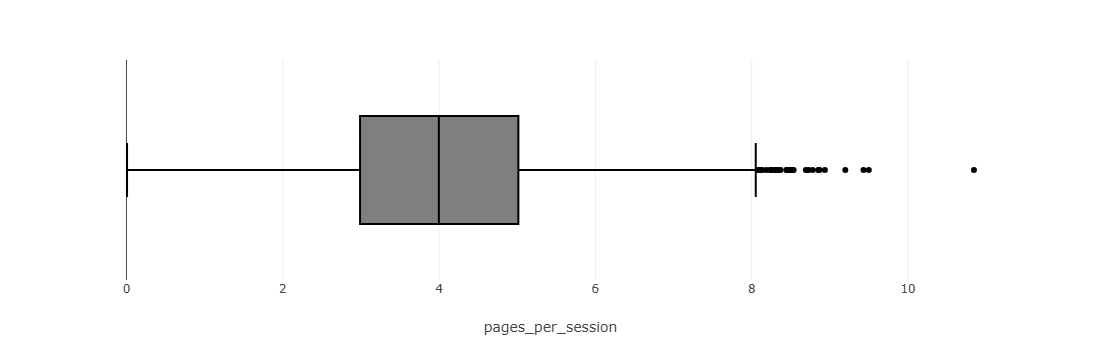

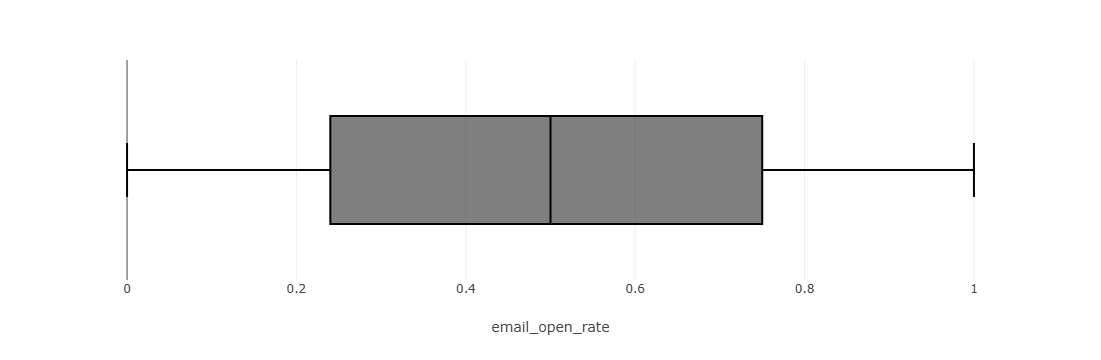

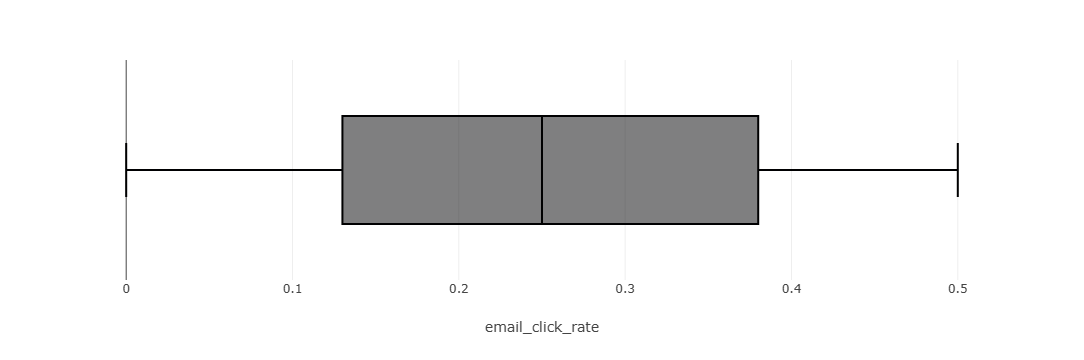

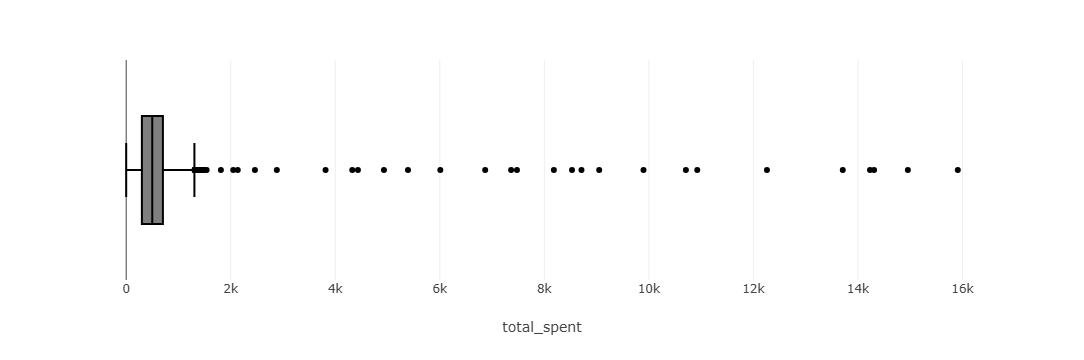

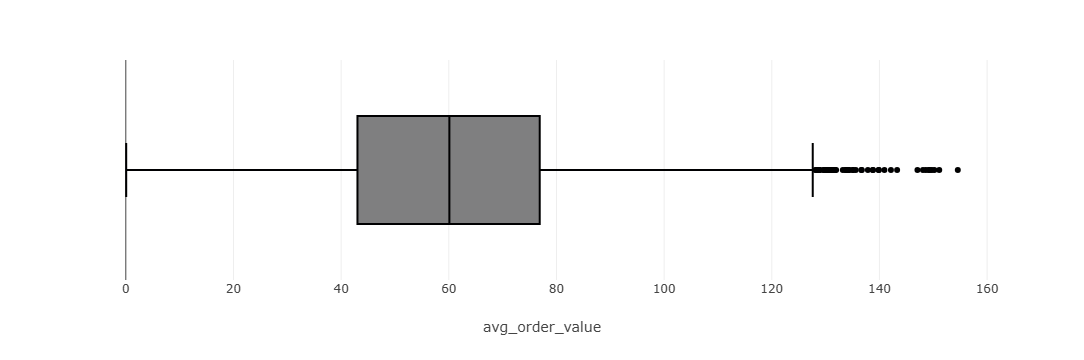

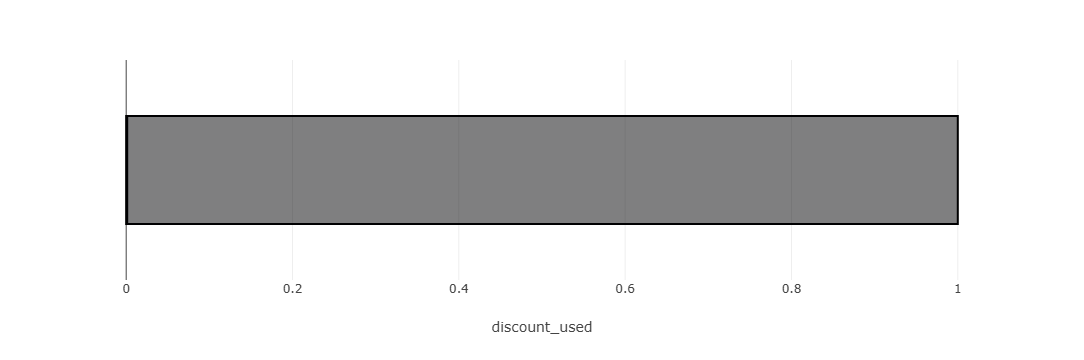

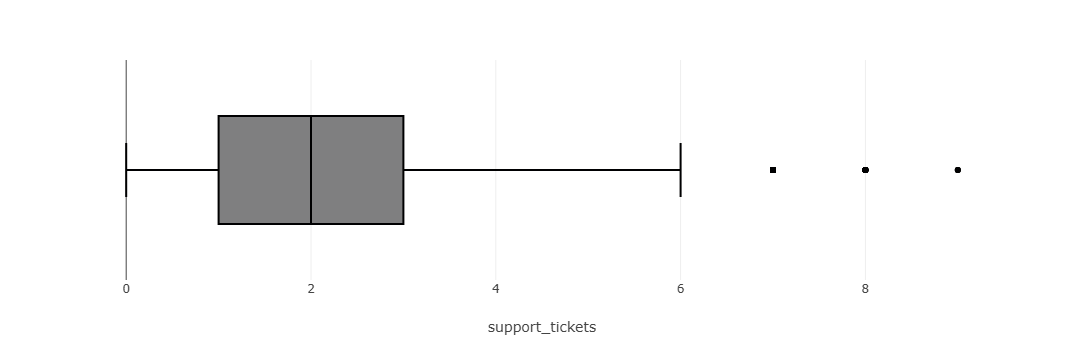

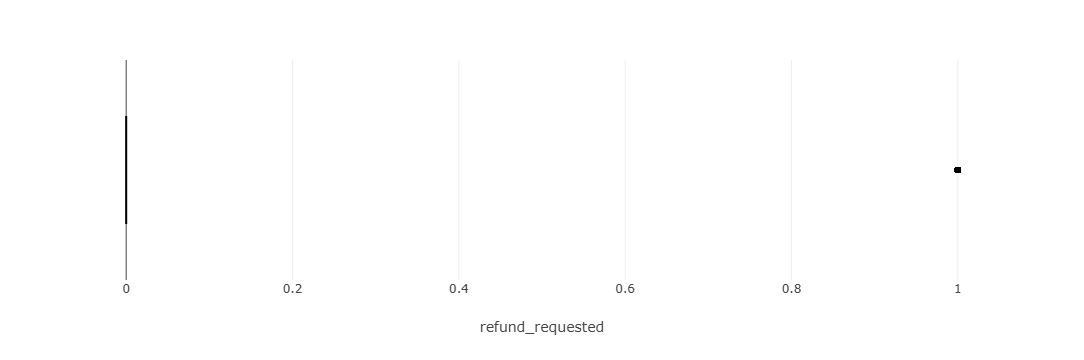

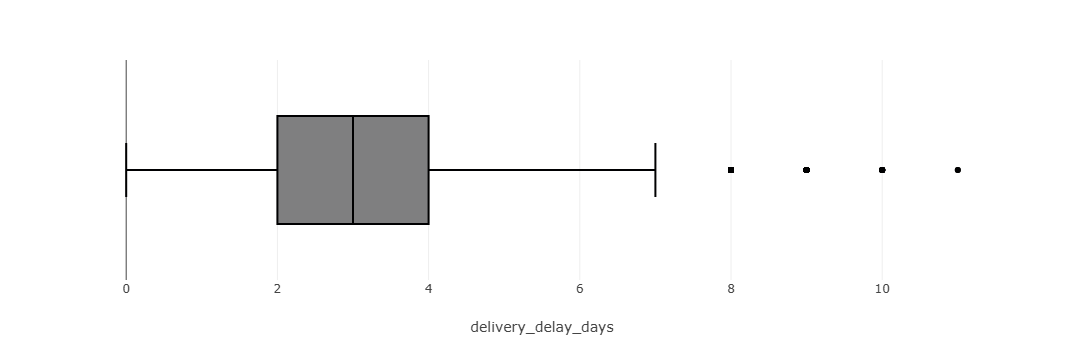

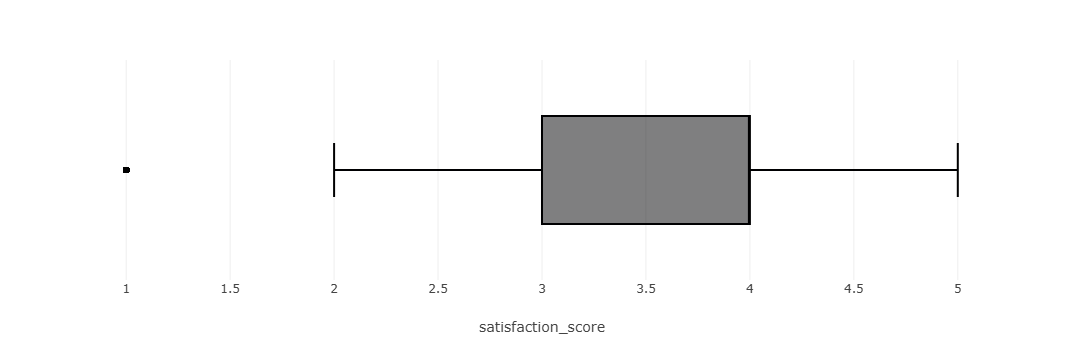

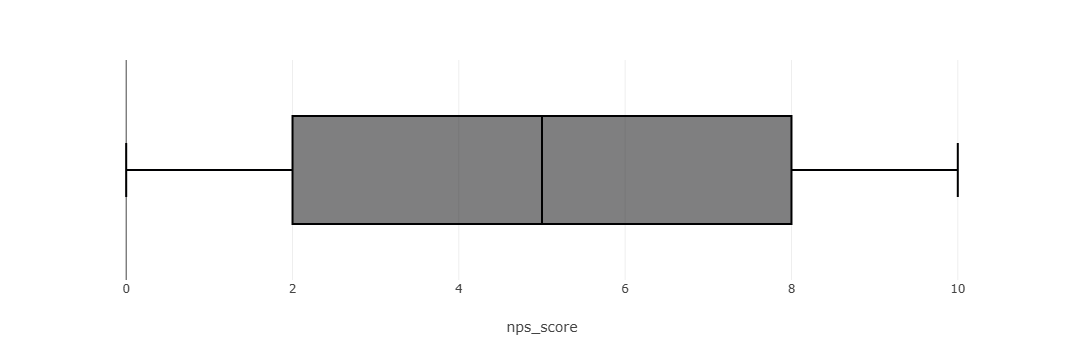

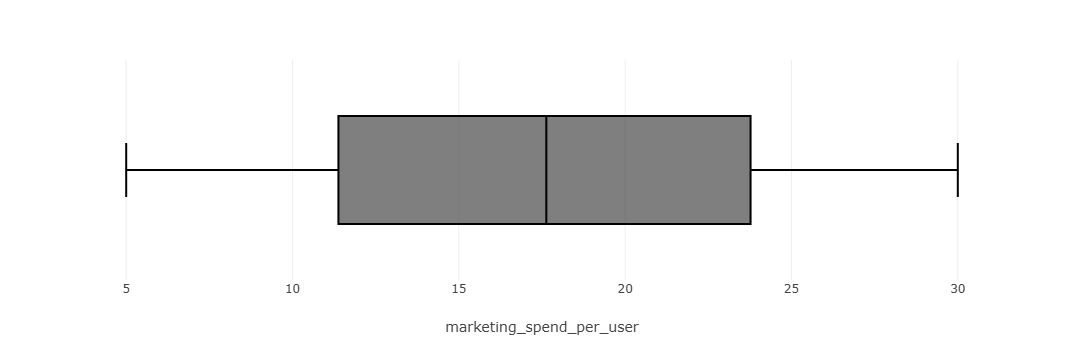

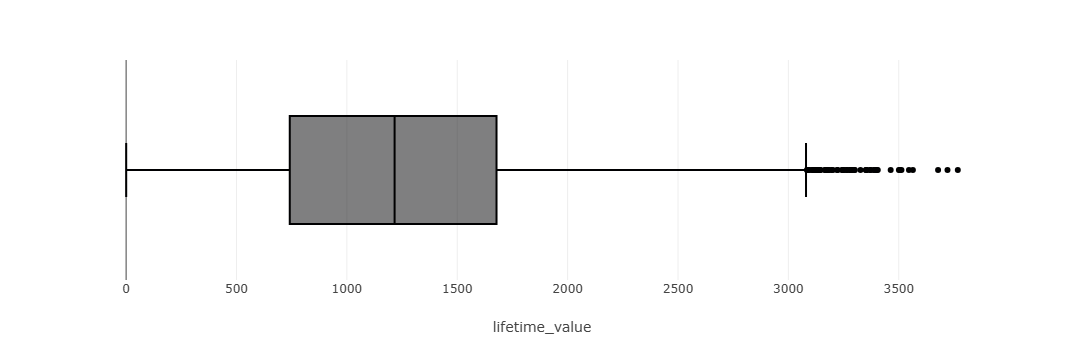

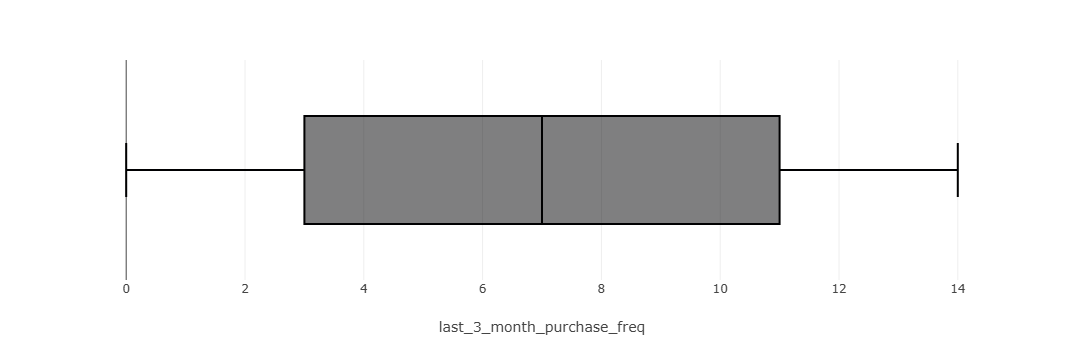

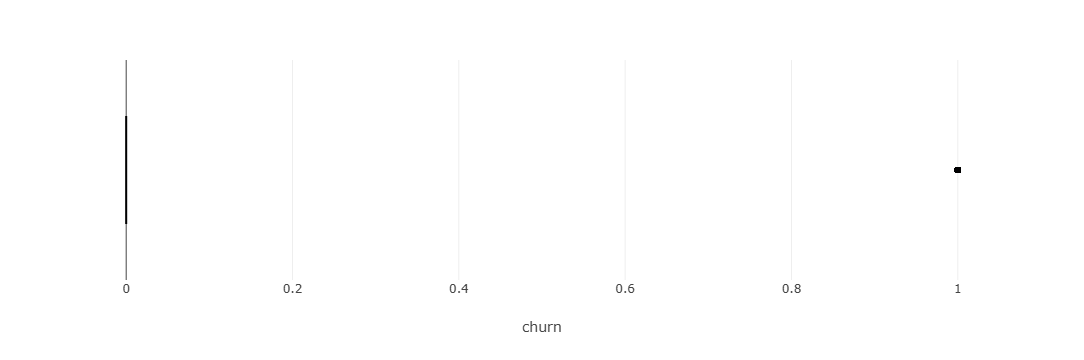

In [7]:
numeric_lst = df.select_dtypes('number').columns
for col in numeric_lst:
    fig = px.box(data_frame = df ,x = col )
    fig.show()

In [8]:
df.shape

(15000, 27)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 27 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   gender                      14262 non-null  object 
 1   age                         13800 non-null  float64
 2   country                     15000 non-null  object 
 3   signup_date                 15000 non-null  object 
 4   last_purchase_date          15000 non-null  object 
 5   acquisition_channel         15000 non-null  object 
 6   device_type                 15000 non-null  object 
 7   subscription_type           15000 non-null  object 
 8   is_premium_user             15000 non-null  int64  
 9   total_visits                15000 non-null  int64  
 10  avg_session_time            15000 non-null  float64
 11  pages_per_session           15000 non-null  float64
 12  email_open_rate             15000 non-null  float64
 13  email_click_rate            150

In [10]:
df.isna().mean().round(4) * 100

gender                        4.92
age                           8.00
country                       0.00
signup_date                   0.00
last_purchase_date            0.00
acquisition_channel           0.00
device_type                   0.00
subscription_type             0.00
is_premium_user               0.00
total_visits                  0.00
avg_session_time              0.00
pages_per_session             0.00
email_open_rate               0.00
email_click_rate              0.00
total_spent                   7.00
avg_order_value               0.00
discount_used                 0.00
support_tickets               0.00
refund_requested              0.00
delivery_delay_days           0.00
payment_method                0.00
satisfaction_score            4.68
nps_score                     0.00
marketing_spend_per_user      0.00
lifetime_value                0.00
last_3_month_purchase_freq    0.00
churn                         0.00
dtype: float64

In [11]:
# filna gender & 'other' replaced by mode 

In [12]:
df['gender'] = df['gender'].fillna(df['gender'].mode()[0])
df.reset_index(drop=True, inplace=True)

In [13]:
gender_mode = df.loc[df['gender'] != 'Other', 'gender'].mode()[0]

In [14]:
df['gender'] = df['gender'].replace('Other', gender_mode)

In [15]:
# 1. حساب متوسط الأعمار للأشخاص الذين أعمارهم 18 فأكثر فقط
valid_age_mean = df[df['age'] >= 18]['age'].mean()

# 2. تعويض القيم المفقودة بهذا المتوسط النظيف
df['age'] = df['age'].fillna(valid_age_mean)

# 3. حذف الأعمار الشاذة الأصغر من 18
df = df[df['age'] >= 18].copy()

# 4. إعادة ضبط الفهرس
df.reset_index(drop=True, inplace=True)

In [16]:
print(df['age'].isnull().sum())
print(df['age'].min())
print(df.shape)

0
18.0
(14484, 27)


In [17]:
df['age'].dtype

dtype('float64')

In [18]:
df.duplicated().sum()

np.int64(0)

In [19]:
df['total_spent'] = df['total_spent'].fillna(df['total_spent'].mean())
df.reset_index(drop=True, inplace=True)

In [20]:
df['satisfaction_score'] = df['satisfaction_score'].fillna(df['satisfaction_score'].mode()[0])
df.reset_index(drop=True, inplace=True)

In [21]:
df.isna().mean().round(4) * 100

gender                        0.0
age                           0.0
country                       0.0
signup_date                   0.0
last_purchase_date            0.0
acquisition_channel           0.0
device_type                   0.0
subscription_type             0.0
is_premium_user               0.0
total_visits                  0.0
avg_session_time              0.0
pages_per_session             0.0
email_open_rate               0.0
email_click_rate              0.0
total_spent                   0.0
avg_order_value               0.0
discount_used                 0.0
support_tickets               0.0
refund_requested              0.0
delivery_delay_days           0.0
payment_method                0.0
satisfaction_score            0.0
nps_score                     0.0
marketing_spend_per_user      0.0
lifetime_value                0.0
last_3_month_purchase_freq    0.0
churn                         0.0
dtype: float64

In [22]:
df.shape

(14484, 27)

In [23]:
df.duplicated().sum()

np.int64(0)

In [24]:
# احطياطى 
df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)

In [25]:
df.reset_index(drop=True, inplace=True)

In [26]:
df['signup_date'] = pd.to_datetime(df['signup_date'])
df['last_purchase_date'] = pd.to_datetime(df['last_purchase_date'])
df.reset_index(drop=True, inplace=True)

In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14484 entries, 0 to 14483
Data columns (total 27 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   gender                      14484 non-null  object        
 1   age                         14484 non-null  float64       
 2   country                     14484 non-null  object        
 3   signup_date                 14484 non-null  datetime64[ns]
 4   last_purchase_date          14484 non-null  datetime64[ns]
 5   acquisition_channel         14484 non-null  object        
 6   device_type                 14484 non-null  object        
 7   subscription_type           14484 non-null  object        
 8   is_premium_user             14484 non-null  int64         
 9   total_visits                14484 non-null  int64         
 10  avg_session_time            14484 non-null  float64       
 11  pages_per_session           14484 non-null  float64   

In [28]:
print("\nNumerical Columns:")
print(df.select_dtypes(include='number').columns.tolist())

print("\nCategorical Columns:")
print(df.select_dtypes(include='object').columns.tolist())


Numerical Columns:
['age', 'is_premium_user', 'total_visits', 'avg_session_time', 'pages_per_session', 'email_open_rate', 'email_click_rate', 'total_spent', 'avg_order_value', 'discount_used', 'support_tickets', 'refund_requested', 'delivery_delay_days', 'satisfaction_score', 'nps_score', 'marketing_spend_per_user', 'lifetime_value', 'last_3_month_purchase_freq', 'churn']

Categorical Columns:
['gender', 'country', 'acquisition_channel', 'device_type', 'subscription_type', 'payment_method']


In [29]:
for col in df.select_dtypes(include='object'):
    print(f"\n--- {col} ---")
    print(df[col].value_counts(dropna=False).head(20))


--- gender ---
gender
Male      8028
Female    6456
Name: count, dtype: int64

--- country ---
country
Germany       2962
India         2917
Bangladesh    2878
USA           2864
UK            2863
Name: count, dtype: int64

--- acquisition_channel ---
acquisition_channel
Organic         2954
Google Ads      2936
Facebook Ads    2908
Email           2843
Referral        2843
Name: count, dtype: int64

--- device_type ---
device_type
Tablet     4883
Mobile     4825
Desktop    4776
Name: count, dtype: int64

--- subscription_type ---
subscription_type
Monthly    7412
Annual     7072
Name: count, dtype: int64

--- payment_method ---
payment_method
UPI       2989
PayPal    2907
SEPA      2892
BKash     2862
Card      2834
Name: count, dtype: int64


In [30]:
df.describe()

,age,signup_date,last_purchase_date,is_premium_user,total_visits,avg_session_time,pages_per_session,email_open_rate,email_click_rate,total_spent,...,discount_used,support_tickets,refund_requested,delivery_delay_days,satisfaction_score,nps_score,marketing_spend_per_user,lifetime_value,last_3_month_purchase_freq,churn
count,14484.000000,14484,14484,14484.000000,14484.000000,14484.000000,14484.000000,14484.000000,14484.000000,14484.000000,...,14484.000000,14484.000000,14484.000000,14484.000000,14484.000000,14484.000000,14484.000000,14484.000000,14484.000000,14484.000000
mean,36.053448,2023-05-16 03:28:52.891466496,2024-02-05 07:51:44.888152320,0.303922,14.995236,8.024426,4.004610,0.496277,0.251320,524.372779,...,0.495167,1.997929,0.147542,2.977907,3.604943,4.968241,17.559387,1236.691641,6.975559,0.153480
min,18.000000,2022-01-01 00:00:00,2023-01-01 00:00:00,0.000000,3.000000,0.006095,0.007845,0.000000,0.000000,0.267291,...,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,5.000000,0.368886,0.000000,0.000000
25%,30.000000,2022-09-03 18:00:00,2023-07-18 00:00:00,0.000000,12.000000,5.982507,2.984523,0.240000,0.130000,316.943152,...,0.000000,1.000000,0.000000,2.000000,3.000000,2.000000,11.360000,741.815722,3.000000,0.000000
50%,36.053448,2023-05-20 00:00:00,2024-02-08 00:00:00,0.000000,15.000000,8.000755,3.998767,0.500000,0.250000,524.372779,...,0.000000,2.000000,0.000000,3.000000,4.000000,5.000000,17.590000,1216.973894,7.000000,0.000000
75%,41.000000,2024-01-22 00:00:00,2024-08-26 00:00:00,1.000000,18.000000,10.062119,5.020113,0.750000,0.380000,683.945433,...,1.000000,3.000000,0.000000,4.000000,4.000000,8.000000,23.752500,1677.997537,11.000000,0.000000
max,95.000000,2024-09-26 00:00:00,2025-03-10 00:00:00,1.000000,31.000000,19.123716,10.843172,1.000000,0.500000,15910.431879,...,1.000000,9.000000,1.000000,11.000000,5.000000,10.000000,30.000000,3767.490455,14.000000,1.000000
std,9.141390,NaN,NaN,0.459965,3.900604,2.993610,1.480783,0.289907,0.144616,455.578143,...,0.499994,1.421711,0.354658,1.720530,1.066571,3.157333,7.181510,658.281543,4.322092,0.360462


In [31]:
df.describe()

,age,signup_date,last_purchase_date,is_premium_user,total_visits,avg_session_time,pages_per_session,email_open_rate,email_click_rate,total_spent,...,discount_used,support_tickets,refund_requested,delivery_delay_days,satisfaction_score,nps_score,marketing_spend_per_user,lifetime_value,last_3_month_purchase_freq,churn
count,14484.000000,14484,14484,14484.000000,14484.000000,14484.000000,14484.000000,14484.000000,14484.000000,14484.000000,...,14484.000000,14484.000000,14484.000000,14484.000000,14484.000000,14484.000000,14484.000000,14484.000000,14484.000000,14484.000000
mean,36.053448,2023-05-16 03:28:52.891466496,2024-02-05 07:51:44.888152320,0.303922,14.995236,8.024426,4.004610,0.496277,0.251320,524.372779,...,0.495167,1.997929,0.147542,2.977907,3.604943,4.968241,17.559387,1236.691641,6.975559,0.153480
min,18.000000,2022-01-01 00:00:00,2023-01-01 00:00:00,0.000000,3.000000,0.006095,0.007845,0.000000,0.000000,0.267291,...,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,5.000000,0.368886,0.000000,0.000000
25%,30.000000,2022-09-03 18:00:00,2023-07-18 00:00:00,0.000000,12.000000,5.982507,2.984523,0.240000,0.130000,316.943152,...,0.000000,1.000000,0.000000,2.000000,3.000000,2.000000,11.360000,741.815722,3.000000,0.000000
50%,36.053448,2023-05-20 00:00:00,2024-02-08 00:00:00,0.000000,15.000000,8.000755,3.998767,0.500000,0.250000,524.372779,...,0.000000,2.000000,0.000000,3.000000,4.000000,5.000000,17.590000,1216.973894,7.000000,0.000000
75%,41.000000,2024-01-22 00:00:00,2024-08-26 00:00:00,1.000000,18.000000,10.062119,5.020113,0.750000,0.380000,683.945433,...,1.000000,3.000000,0.000000,4.000000,4.000000,8.000000,23.752500,1677.997537,11.000000,0.000000
max,95.000000,2024-09-26 00:00:00,2025-03-10 00:00:00,1.000000,31.000000,19.123716,10.843172,1.000000,0.500000,15910.431879,...,1.000000,9.000000,1.000000,11.000000,5.000000,10.000000,30.000000,3767.490455,14.000000,1.000000
std,9.141390,NaN,NaN,0.459965,3.900604,2.993610,1.480783,0.289907,0.144616,455.578143,...,0.499994,1.421711,0.354658,1.720530,1.066571,3.157333,7.181510,658.281543,4.322092,0.360462


In [32]:
# حساب الفرق بالأيام بين تاريخ التسجيل وآخر شراء
invalid_dates = df[df['last_purchase_date'] < df['signup_date']]
invalid_dates

,gender,age,country,signup_date,last_purchase_date,acquisition_channel,device_type,subscription_type,is_premium_user,total_visits,...,support_tickets,refund_requested,delivery_delay_days,payment_method,satisfaction_score,nps_score,marketing_spend_per_user,lifetime_value,last_3_month_purchase_freq,churn
1,Male,35.0,Germany,2024-06-16,2024-05-07,Organic,Desktop,Monthly,0,19,...,5,0,3,BKash,3.0,7,15.15,2079.960938,11,0
3,Female,36.0,India,2024-01-28,2023-05-20,Facebook Ads,Tablet,Annual,1,16,...,0,0,2,PayPal,4.0,6,25.65,774.652684,7,0
5,Male,29.0,Germany,2024-05-08,2023-01-20,Google Ads,Mobile,Monthly,0,13,...,2,0,2,SEPA,3.0,10,16.30,467.452413,14,0
12,Female,54.0,Germany,2023-03-14,2023-01-25,Organic,Tablet,Monthly,1,14,...,2,0,3,UPI,4.0,10,8.87,572.988440,2,0
13,Male,36.0,India,2024-09-14,2023-01-31,Google Ads,Tablet,Monthly,1,11,...,3,0,2,Card,5.0,4,6.44,2067.644938,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14460,Male,37.0,USA,2023-10-17,2023-10-02,Referral,Tablet,Annual,0,25,...,3,0,2,UPI,3.0,6,24.45,1349.368379,0,0
14461,Male,21.0,Bangladesh,2024-08-14,2023-05-21,Google Ads,Desktop,Annual,0,14,...,1,0,3,UPI,5.0,1,12.23,2280.324206,12,0
14463,Female,42.0,Germany,2024-03-30,2023-11-03,Email,Tablet,Annual,0,12,...,3,0,4,UPI,4.0,0,13.53,440.198307,8,0
14471,Female,26.0,USA,2024-02-20,2023-05-21,Email,Mobile,Annual,0,16,...,3,0,1,BKash,3.0,6,28.90,671.758883,12,0


In [33]:
# جعل تاريخ الشراء يساوي تاريخ التسجيل إذا كان تاريخ الشراء أسبق
df.loc[df['last_purchase_date'] < df['signup_date'], 'signup_date'] = df['last_purchase_date']

In [34]:
invalid_dates = df[df['last_purchase_date'] < df['signup_date']]
invalid_dates

,gender,age,country,signup_date,last_purchase_date,acquisition_channel,device_type,subscription_type,is_premium_user,total_visits,...,support_tickets,refund_requested,delivery_delay_days,payment_method,satisfaction_score,nps_score,marketing_spend_per_user,lifetime_value,last_3_month_purchase_freq,churn


In [35]:
# الفرق بين التصفح و عملية الشراء للعميل 
df['customer_tenure_days'] = (df['last_purchase_date'] - df['signup_date']).dt.days
df['customer_tenure_days']

0        966
1          0
2        249
3          0
4        261
        ... 
14479    131
14480    683
14481    419
14482    955
14483    258
Name: customer_tenure_days, Length: 14484, dtype: int64

In [36]:
df.shape

(14484, 28)

In [37]:
df.describe()

,age,signup_date,last_purchase_date,is_premium_user,total_visits,avg_session_time,pages_per_session,email_open_rate,email_click_rate,total_spent,...,support_tickets,refund_requested,delivery_delay_days,satisfaction_score,nps_score,marketing_spend_per_user,lifetime_value,last_3_month_purchase_freq,churn,customer_tenure_days
count,14484.000000,14484,14484,14484.000000,14484.000000,14484.000000,14484.000000,14484.000000,14484.000000,14484.000000,...,14484.000000,14484.000000,14484.000000,14484.000000,14484.000000,14484.000000,14484.000000,14484.000000,14484.000000,14484.000000
mean,36.053448,2023-03-24 03:03:07.903894016,2024-02-05 07:51:44.888152320,0.303922,14.995236,8.024426,4.004610,0.496277,0.251320,524.372779,...,1.997929,0.147542,2.977907,3.604943,4.968241,17.559387,1236.691641,6.975559,0.153480,318.200428
min,18.000000,2022-01-01 00:00:00,2023-01-01 00:00:00,0.000000,3.000000,0.006095,0.007845,0.000000,0.000000,0.267291,...,0.000000,0.000000,0.000000,1.000000,0.000000,5.000000,0.368886,0.000000,0.000000,0.000000
25%,30.000000,2022-09-03 18:00:00,2023-07-18 00:00:00,0.000000,12.000000,5.982507,2.984523,0.240000,0.130000,316.943152,...,1.000000,0.000000,2.000000,3.000000,2.000000,11.360000,741.815722,3.000000,0.000000,0.000000
50%,36.053448,2023-03-22 00:00:00,2024-02-08 00:00:00,0.000000,15.000000,8.000755,3.998767,0.500000,0.250000,524.372779,...,2.000000,0.000000,3.000000,4.000000,5.000000,17.590000,1216.973894,7.000000,0.000000,266.000000
75%,41.000000,2023-09-25 06:00:00,2024-08-26 00:00:00,1.000000,18.000000,10.062119,5.020113,0.750000,0.380000,683.945433,...,3.000000,0.000000,4.000000,4.000000,8.000000,23.752500,1677.997537,11.000000,0.000000,527.000000
max,95.000000,2024-09-26 00:00:00,2025-03-10 00:00:00,1.000000,31.000000,19.123716,10.843172,1.000000,0.500000,15910.431879,...,9.000000,1.000000,11.000000,5.000000,10.000000,30.000000,3767.490455,14.000000,1.000000,1157.000000
std,9.141390,NaN,NaN,0.459965,3.900604,2.993610,1.480783,0.289907,0.144616,455.578143,...,1.421711,0.354658,1.720530,1.066571,3.157333,7.181510,658.281543,4.322092,0.360462,297.601912


In [38]:
df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)

In [39]:
df.shape

(14484, 28)

In [40]:
numeric_columns = df.select_dtypes(include='number').columns

print(numeric_columns)

Index(['age', 'is_premium_user', 'total_visits', 'avg_session_time',
       'pages_per_session', 'email_open_rate', 'email_click_rate',
       'total_spent', 'avg_order_value', 'discount_used', 'support_tickets',
       'refund_requested', 'delivery_delay_days', 'satisfaction_score',
       'nps_score', 'marketing_spend_per_user', 'lifetime_value',
       'last_3_month_purchase_freq', 'churn', 'customer_tenure_days'],
      dtype='object')


In [41]:
df[numeric_columns].describe()

,age,is_premium_user,total_visits,avg_session_time,pages_per_session,email_open_rate,email_click_rate,total_spent,avg_order_value,discount_used,support_tickets,refund_requested,delivery_delay_days,satisfaction_score,nps_score,marketing_spend_per_user,lifetime_value,last_3_month_purchase_freq,churn,customer_tenure_days
count,14484.000000,14484.000000,14484.000000,14484.000000,14484.000000,14484.000000,14484.000000,14484.000000,14484.000000,14484.000000,14484.000000,14484.000000,14484.000000,14484.000000,14484.000000,14484.000000,14484.000000,14484.000000,14484.000000,14484.000000
mean,36.053448,0.303922,14.995236,8.024426,4.004610,0.496277,0.251320,524.372779,60.120990,0.495167,1.997929,0.147542,2.977907,3.604943,4.968241,17.559387,1236.691641,6.975559,0.153480,318.200428
std,9.141390,0.459965,3.900604,2.993610,1.480783,0.289907,0.144616,455.578143,24.728205,0.499994,1.421711,0.354658,1.720530,1.066571,3.157333,7.181510,658.281543,4.322092,0.360462,297.601912
min,18.000000,0.000000,3.000000,0.006095,0.007845,0.000000,0.000000,0.267291,0.071596,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,5.000000,0.368886,0.000000,0.000000,0.000000
25%,30.000000,0.000000,12.000000,5.982507,2.984523,0.240000,0.130000,316.943152,43.110102,0.000000,1.000000,0.000000,2.000000,3.000000,2.000000,11.360000,741.815722,3.000000,0.000000,0.000000
50%,36.053448,0.000000,15.000000,8.000755,3.998767,0.500000,0.250000,524.372779,60.139614,0.000000,2.000000,0.000000,3.000000,4.000000,5.000000,17.590000,1216.973894,7.000000,0.000000,266.000000
75%,41.000000,1.000000,18.000000,10.062119,5.020113,0.750000,0.380000,683.945433,76.894616,1.000000,3.000000,0.000000,4.000000,4.000000,8.000000,23.752500,1677.997537,11.000000,0.000000,527.000000
max,95.000000,1.000000,31.000000,19.123716,10.843172,1.000000,0.500000,15910.431879,154.554696,1.000000,9.000000,1.000000,11.000000,5.000000,10.000000,30.000000,3767.490455,14.000000,1.000000,1157.000000


In [42]:
df.select_dtypes(include='number')

,age,is_premium_user,total_visits,avg_session_time,pages_per_session,email_open_rate,email_click_rate,total_spent,avg_order_value,discount_used,support_tickets,refund_requested,delivery_delay_days,satisfaction_score,nps_score,marketing_spend_per_user,lifetime_value,last_3_month_purchase_freq,churn,customer_tenure_days
0,52.0,1,7,13.903745,5.415164,0.67,0.26,559.524958,65.246704,0,0,0,3,3.0,10,27.56,915.310827,14,0,966
1,35.0,0,19,5.112528,5.352441,0.70,0.37,356.491344,48.473887,1,5,0,3,3.0,7,15.15,2079.960938,11,0,0
2,27.0,1,18,9.742749,3.594719,0.47,0.44,689.332196,77.815371,0,1,0,2,5.0,6,13.51,1379.150885,9,0,249
3,36.0,1,16,9.642654,2.949531,0.58,0.37,445.429636,71.712192,0,0,0,2,4.0,6,25.65,774.652684,7,0,0
4,29.0,0,12,7.791291,2.405539,0.05,0.16,686.286022,44.990246,1,2,1,4,3.0,1,12.39,87.680409,11,0,261
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14479,24.0,0,11,10.852688,1.420191,0.96,0.02,60.073013,57.091409,0,3,0,3,4.0,2,16.96,796.486833,9,0,131
14480,26.0,0,17,6.669842,5.170127,0.86,0.42,468.173941,44.112735,0,3,0,2,4.0,6,23.86,2155.987233,0,0,683
14481,42.0,0,8,7.936580,3.349345,0.55,0.33,524.372779,51.775195,1,3,0,5,4.0,4,12.55,614.326226,14,0,419
14482,31.0,1,15,8.808861,6.169827,0.16,0.09,625.011233,69.094575,1,5,1,1,3.0,1,19.03,849.936622,8,1,955


In [43]:
df.shape

(14484, 28)

In [44]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14484 entries, 0 to 14483
Data columns (total 28 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   gender                      14484 non-null  object        
 1   age                         14484 non-null  float64       
 2   country                     14484 non-null  object        
 3   signup_date                 14484 non-null  datetime64[ns]
 4   last_purchase_date          14484 non-null  datetime64[ns]
 5   acquisition_channel         14484 non-null  object        
 6   device_type                 14484 non-null  object        
 7   subscription_type           14484 non-null  object        
 8   is_premium_user             14484 non-null  int64         
 9   total_visits                14484 non-null  int64         
 10  avg_session_time            14484 non-null  float64       
 11  pages_per_session           14484 non-null  float64   

In [45]:
# AGE 
px.histogram(
    df,
    x='age',
    nbins=18,
    title='Distribution of Customers by Age'
)

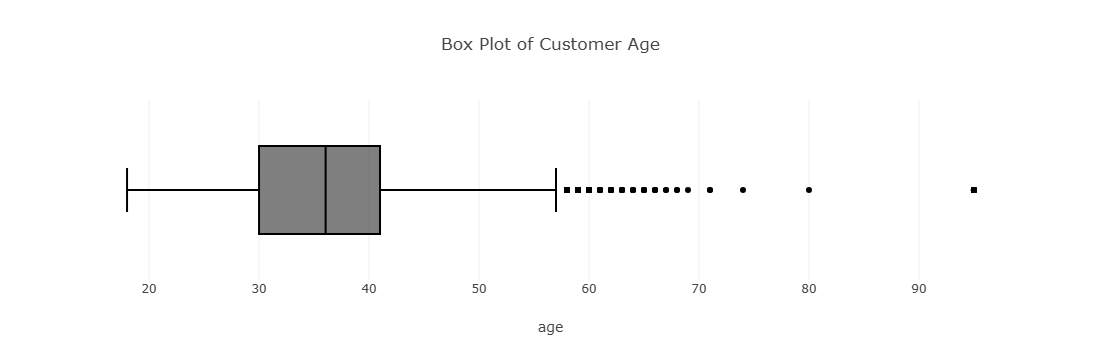

In [46]:
px.box(
    df,
    x='age',
    title='Box Plot of Customer Age'
)

In [47]:
df['is_premium_user'].value_counts()

is_premium_user
0    10082
1     4402
Name: count, dtype: int64

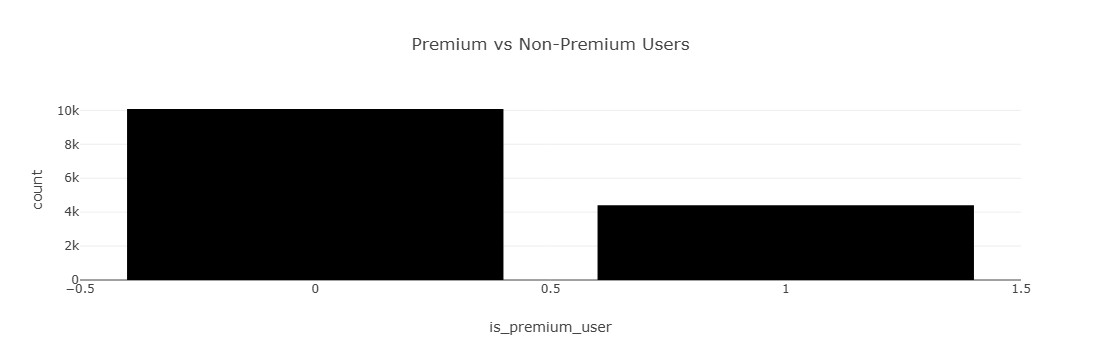

In [48]:
px.bar(
    df['is_premium_user'].value_counts().reset_index(),
    x='is_premium_user',
    y='count',
    title='Premium vs Non-Premium Users'
)

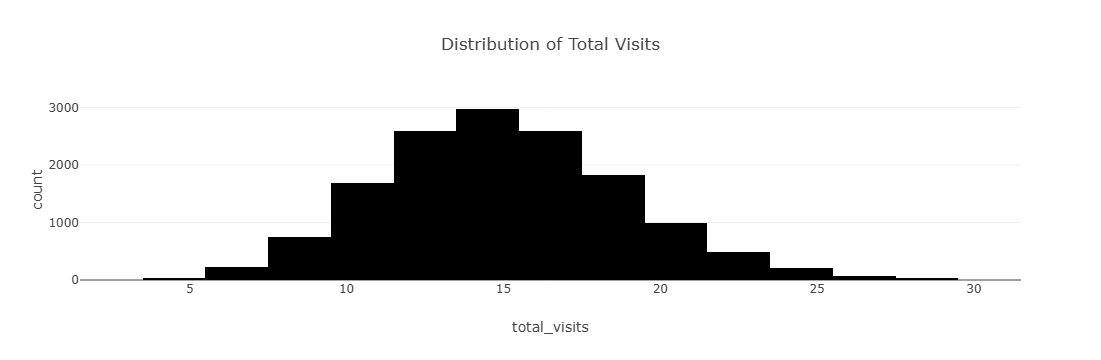

In [49]:
#total_visits 

px.histogram(
    df,
    x='total_visits',
    nbins=20,
    title='Distribution of Total Visits'
)

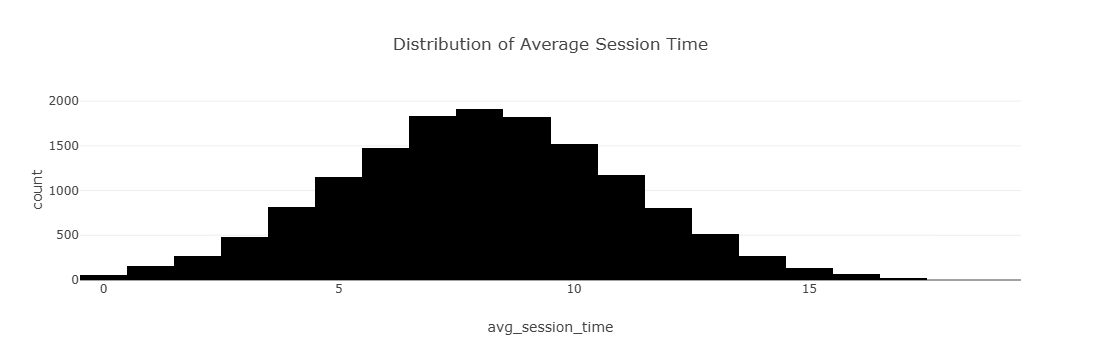

In [50]:
#avg_session_time
px.histogram(
    df,
    x='avg_session_time',
    nbins=20,
    title='Distribution of Average Session Time'
)

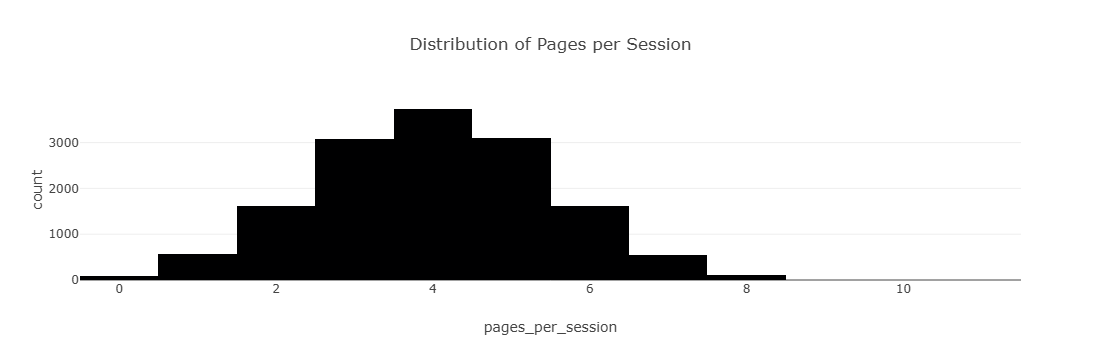

In [51]:
#pages_per_session
px.histogram(
    df,
    x='pages_per_session',
    nbins=20,
    title='Distribution of Pages per Session'
)

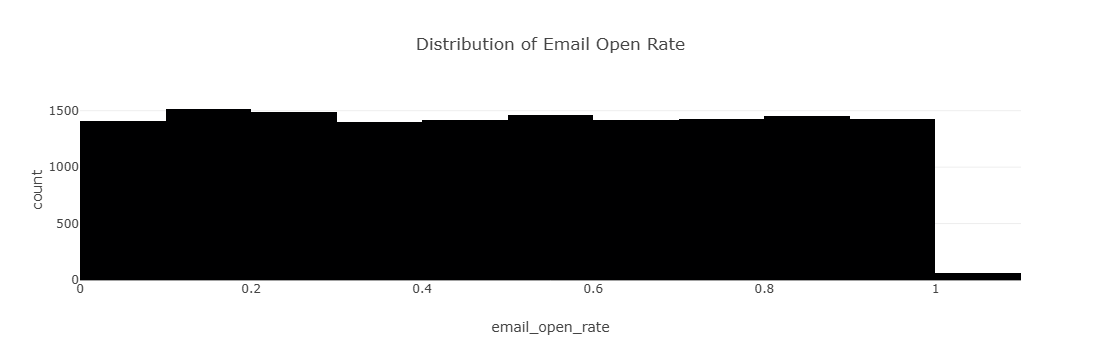

In [52]:
# email_open_rate بيقيس نسبة الإيميلات التسويقية اللي العميل فتحها. email_open_rate
px.histogram(
    df,
    x='email_open_rate',
    nbins=20,
    title='Distribution of Email Open Rate'
)

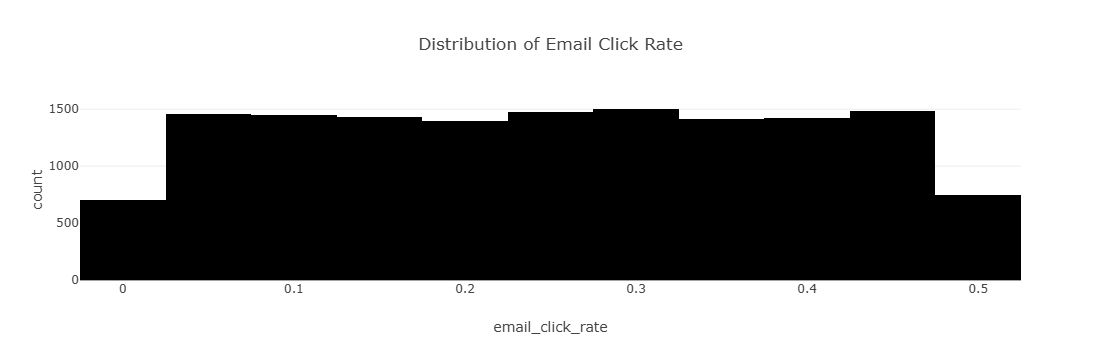

In [53]:
# Open Rate بيقول إن العميل فتح الإيميل، لكن Click Rate بيقول إن العميل اتفاعل مع المحتوى وضغط على شيء داخله. email_click_rate
px.histogram(
    df,
    x='email_click_rate',
    nbins=20,
    title='Distribution of Email Click Rate'
)

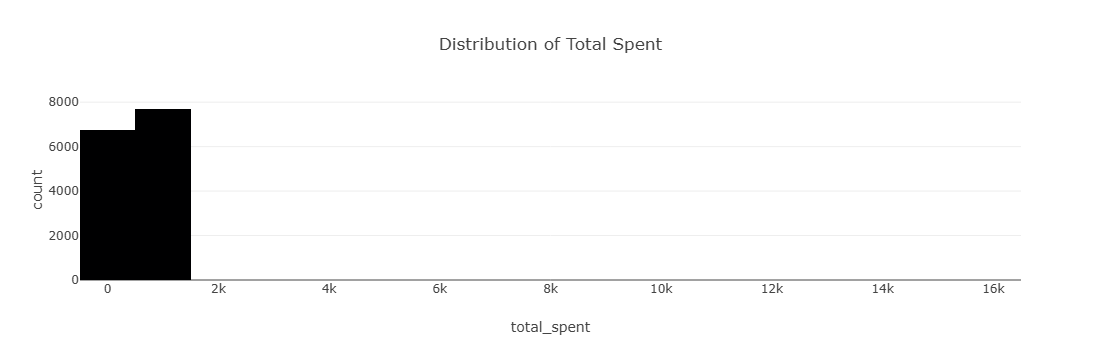

In [54]:
# total_spent 
px.histogram(
    df,
    x='total_spent',
    nbins=20,
    title='Distribution of Total Spent'
)

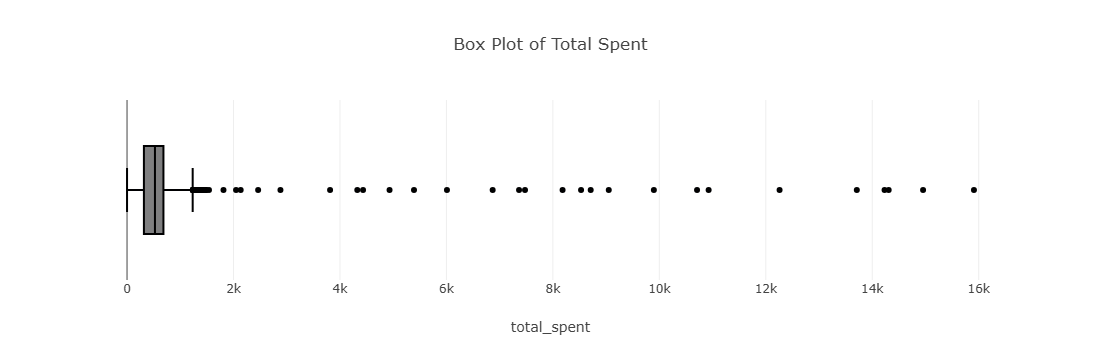

In [55]:
px.box(
    df,
    x='total_spent',
    title='Box Plot of Total Spent'
)

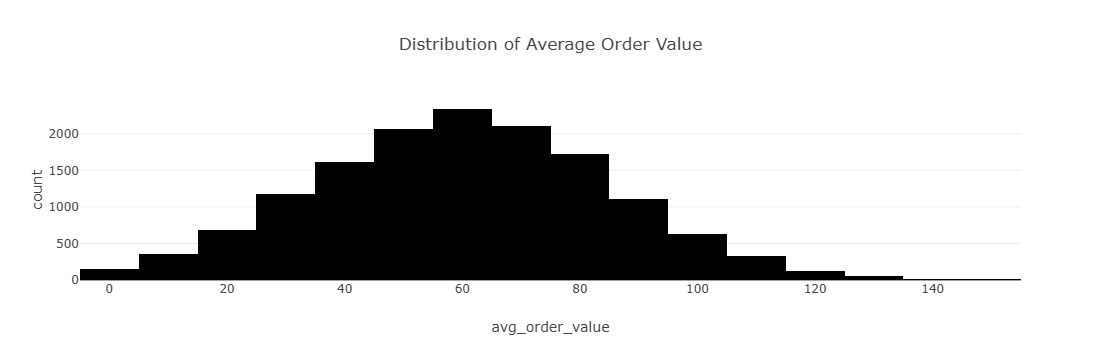

In [56]:
# avg_order_value  العميل في المتوسط بيدفع كام في الطلب الواحد. 
#أغلب الطلبات متوسط قيمتها فين.
# هل فيه عملاء عندهم Average Order Value مرتفع جدًا.

px.histogram(
    df,
    x='avg_order_value',
    nbins=20,
    title='Distribution of Average Order Value'
)

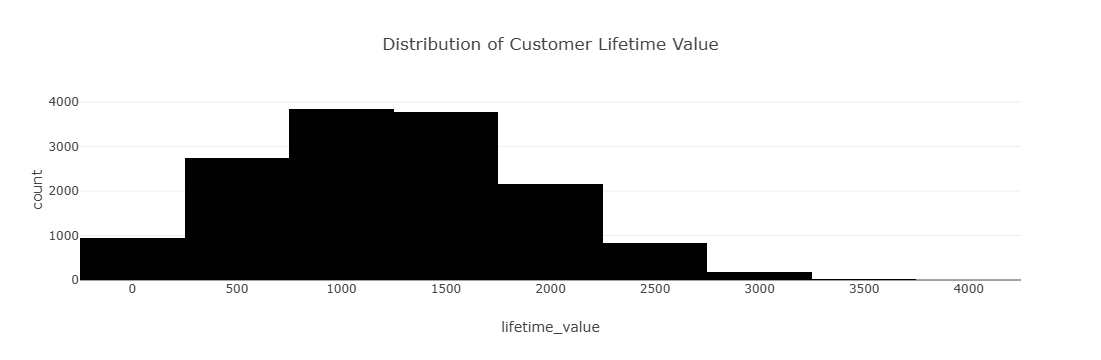

In [57]:
# lifetime_value  القيمة الإجمالية المتوقعة أو المتحققة من العميل خلال فترة علاقته بالشركة.
# ده متغير مهم جدًا في مشروع الـ Customer Analytics، لأنه بيساعدنا نفهم قيمة العميل للشركة على مدى علاقته بها.
px.histogram(
    df,
    x='lifetime_value',
    nbins=10,
    title='Distribution of Customer Lifetime Value'
)

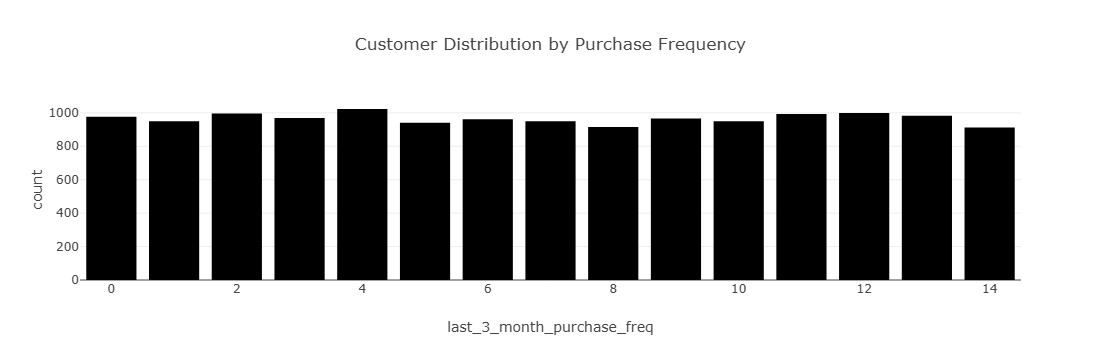

In [58]:
#last_3_month_purchase_freq  عدد مرات الشراء خلال آخر 3 شهور
purchase_freq = df['last_3_month_purchase_freq'].value_counts().sort_index().reset_index()
purchase_freq = (
    df['last_3_month_purchase_freq']
    .value_counts()
    .reset_index()
)

px.bar(
    purchase_freq,
    x='last_3_month_purchase_freq',
    y='count',
    title='Customer Distribution by Purchase Frequency'
)

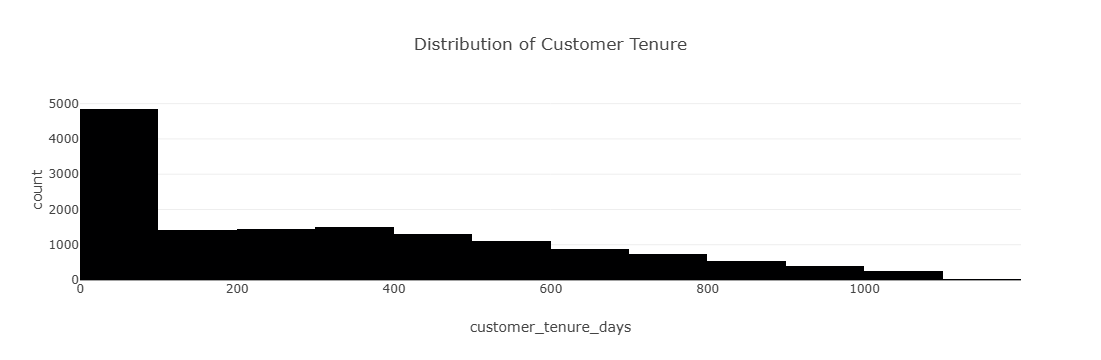

In [59]:
# customer_tenure_days  الفرق بين التصفح و عملية الشراء للعميل  
px.histogram(
    df,
    x='customer_tenure_days',
    nbins=20,
    title='Distribution of Customer Tenure'
)

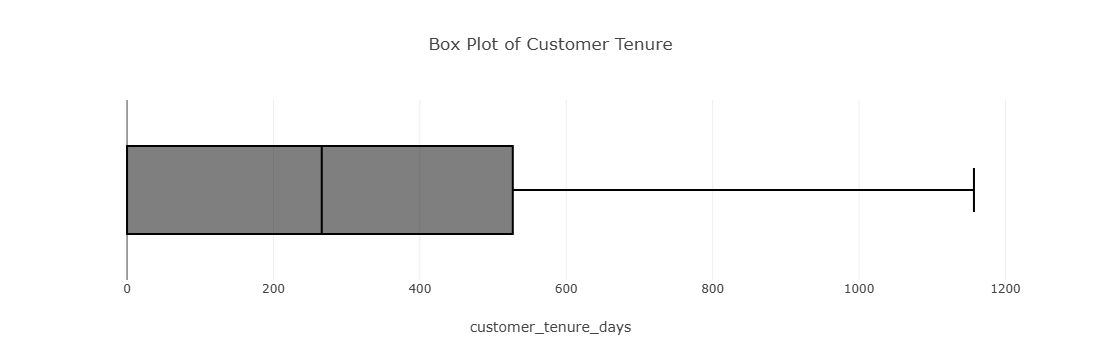

In [60]:
# بعد ما عالجنا القيم السالبة و خلنيها بصفر و اعتبرنا ان العميل دخل و شاف المنتج و اشتراه على طول 
px.box(
    df,
    x='customer_tenure_days',
    title='Box Plot of Customer Tenure'
)

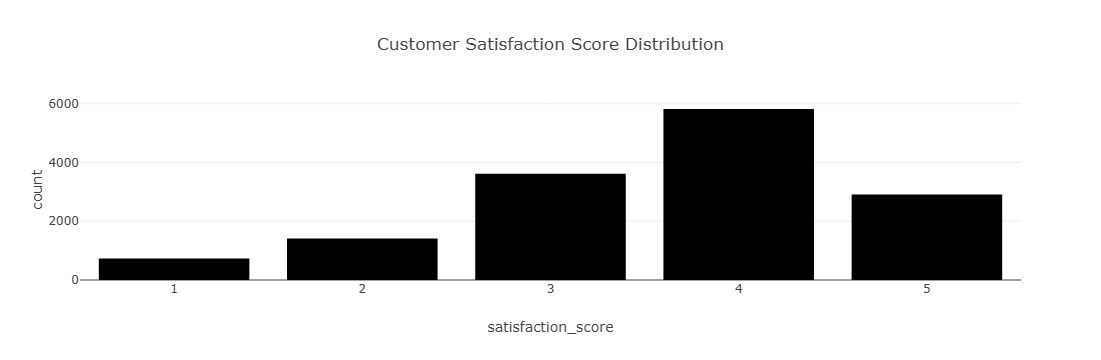

In [61]:
# satisfaction_score
satisfaction_distribution = (
    df['satisfaction_score']
    .value_counts()
    .sort_index()
    .reset_index()
)

px.bar(
    satisfaction_distribution,
    x='satisfaction_score',
    y='count',
    title='Customer Satisfaction Score Distribution'
)

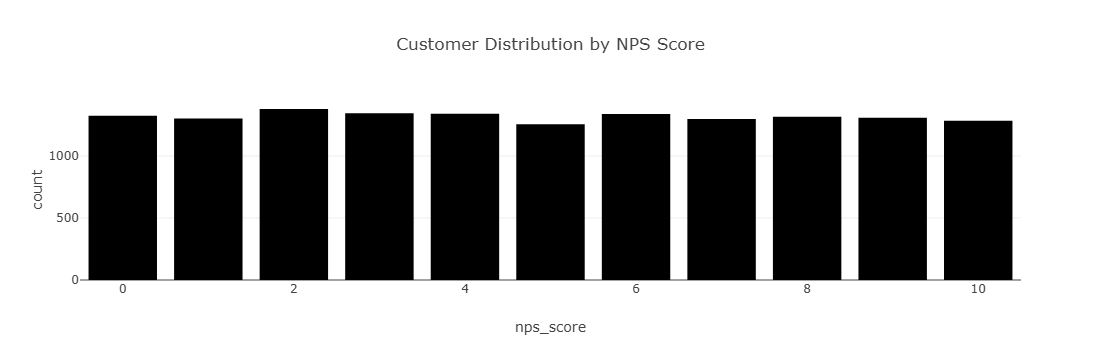

In [62]:
# nps_score  بيقيس مدى استعداد العميل إنه يوصي بالشركة/الخدمة لشخص تاني.
nps_distribution = (
    df['nps_score']
    .value_counts()
    .sort_index()
    .reset_index()
)
px.bar(
    nps_distribution,
    x='nps_score',
    y='count',
    title='Customer Distribution by NPS Score'
)

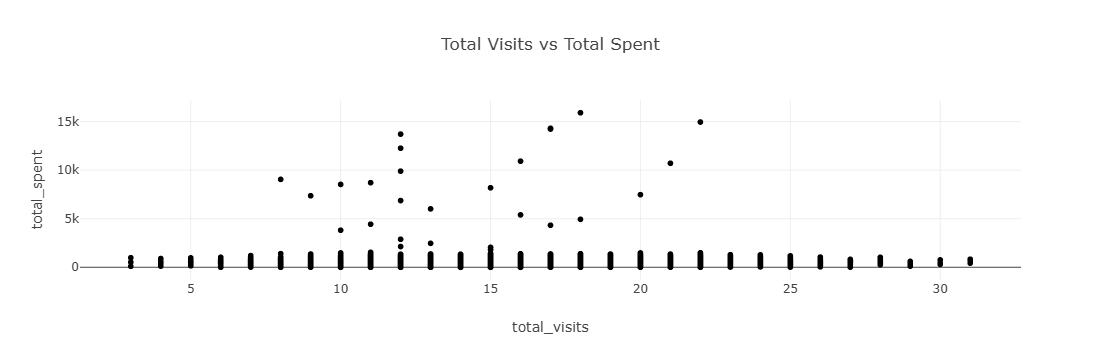

In [63]:
# Numerical × Numerical
# total_visits × total_spent
# هل العملاء الأكثر زيارة للموقع/المنصة بينفقوا أكثر؟ 

px.scatter(
    df,
    x='total_visits',
    y='total_spent',
    title='Total Visits vs Total Spent'
)

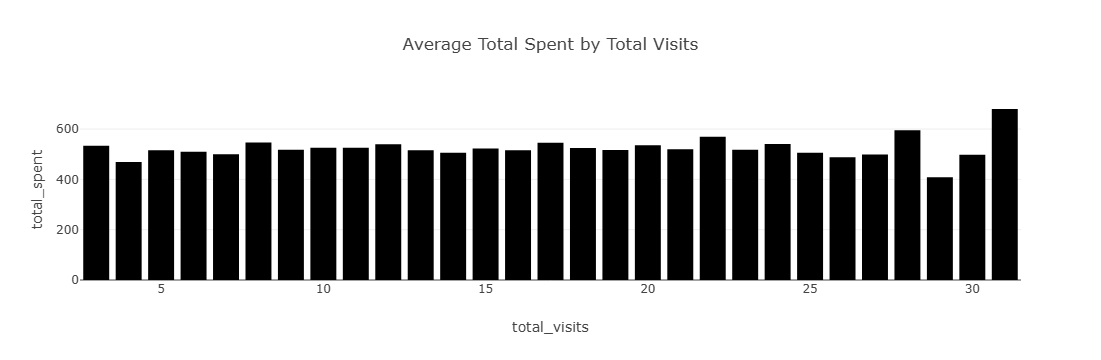

In [64]:
visits_spending = (
    df.groupby('total_visits')['total_spent']
    .mean()
    .reset_index()
)

px.bar(
    visits_spending,
    x='total_visits',
    y='total_spent',
    title='Average Total Spent by Total Visits'
)

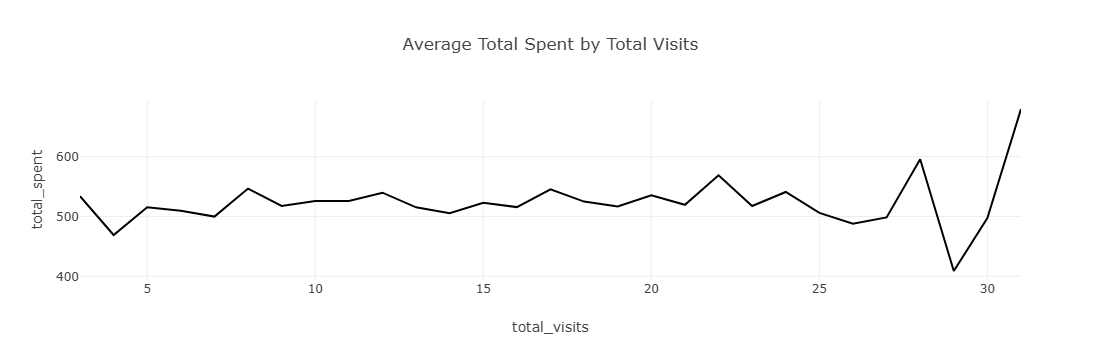

In [65]:
px.line(
    visits_spending,
    x='total_visits',
    y='total_spent',
    title='Average Total Spent by Total Visits'
)

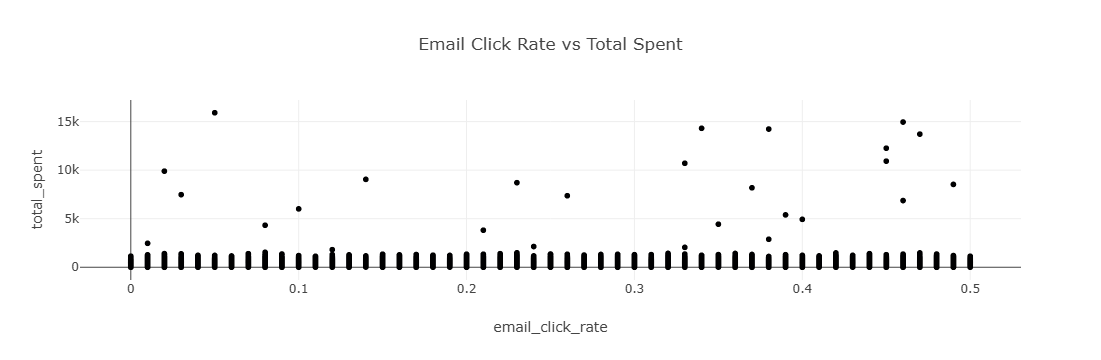

In [66]:
# email_click_rate × total_spent
# هل العملاء الذين يتفاعلون أكثر مع الإيميلات التسويقية ينفقون أكثر؟
px.scatter(
    df,
    x='email_click_rate',
    y='total_spent',
    title='Email Click Rate vs Total Spent'
)

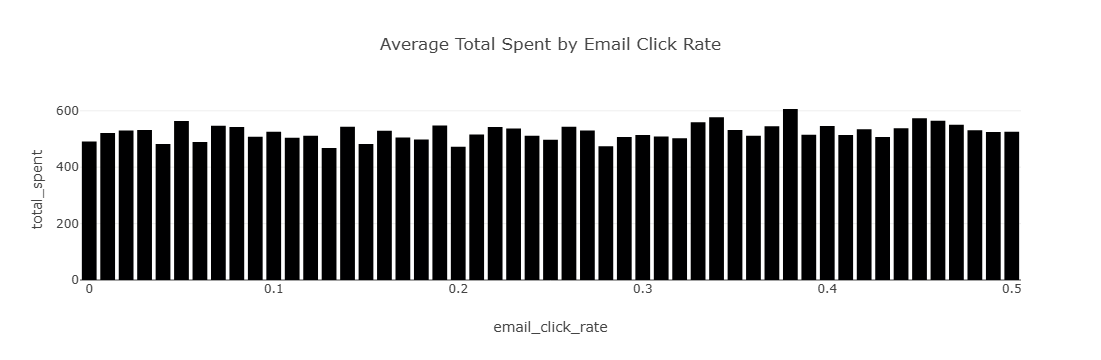

In [67]:
click_spending = (
    df.groupby('email_click_rate')['total_spent']
    .mean()
    .reset_index()
)

px.bar(
    click_spending,
    x='email_click_rate',
    y='total_spent',
    title='Average Total Spent by Email Click Rate'
)

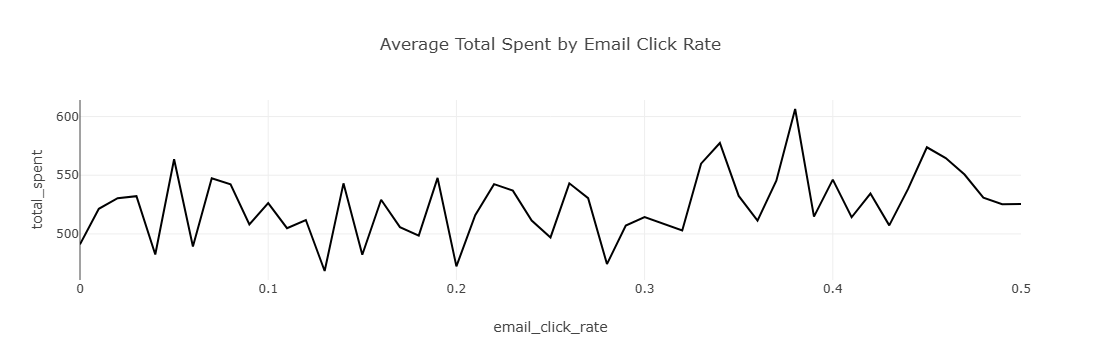

In [68]:
px.line(
    click_spending,
    x='email_click_rate',
    y='total_spent',
    title='Average Total Spent by Email Click Rate'
)

In [69]:
# last_3_month_purchase_freq × lifetime_value
# هل العملاء اللي بيشتروا بشكل متكرر خلال آخر 3 شهور عندهم Lifetime Value أعلى؟ 
purchase_ltv = (
    df.groupby('last_3_month_purchase_freq')['lifetime_value']
    .mean()
    .reset_index()
)
purchase_ltv

,last_3_month_purchase_freq,lifetime_value
0,0,1230.941822
1,1,1231.955195
2,2,1218.319301
3,3,1255.992519
4,4,1225.377339
5,5,1234.461986
6,6,1223.101348
7,7,1227.953727
8,8,1244.096108
9,9,1223.012717


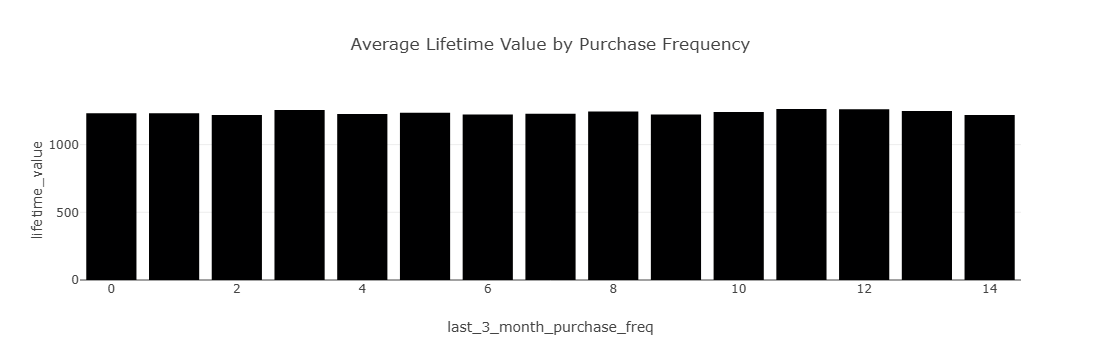

In [70]:
px.bar(
    purchase_ltv,
    x='last_3_month_purchase_freq',
    y='lifetime_value',
    title='Average Lifetime Value by Purchase Frequency'
)

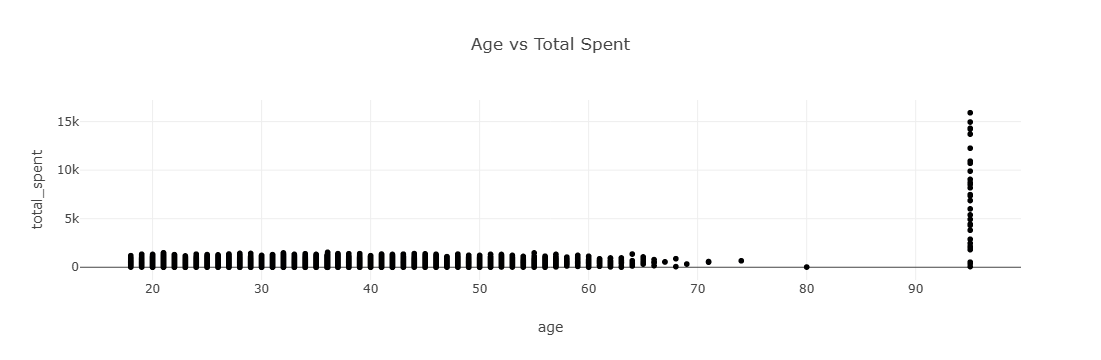

In [71]:
# age × total_spent 
px.scatter(
    df,
    x='age',
    y='total_spent',
    title='Age vs Total Spent'
)

In [72]:
age_spending = (
    df.groupby('age')['total_spent']
    .mean()
    .reset_index()
)

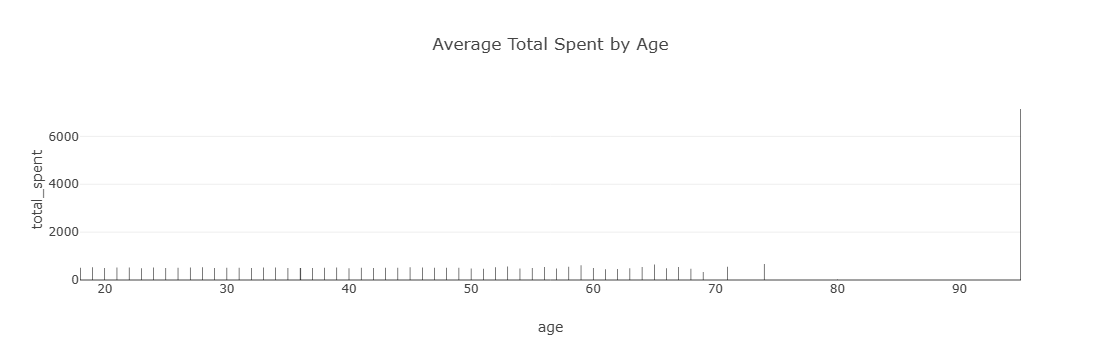

In [73]:
px.bar(
    age_spending,
    x='age',
    y='total_spent',
    title='Average Total Spent by Age'
)

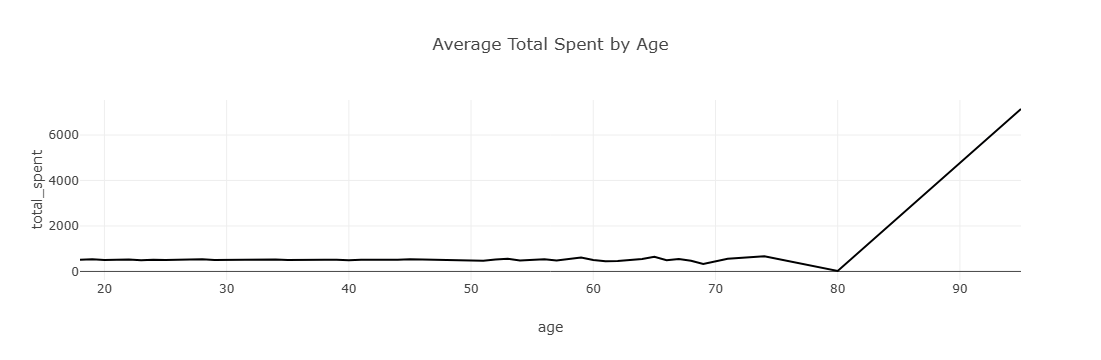

In [74]:
px.line(
    age_spending,
    x='age',
    y='total_spent',
    title='Average Total Spent by Age'
)

In [75]:
# delivery_delay_days × satisfaction_score
# هل زيادة أيام تأخير التوصيل مرتبطة بانخفاض رضا العميل؟

delay_satisfaction = (
    df.groupby('satisfaction_score')['delivery_delay_days']
    .mean()
    .reset_index()
)

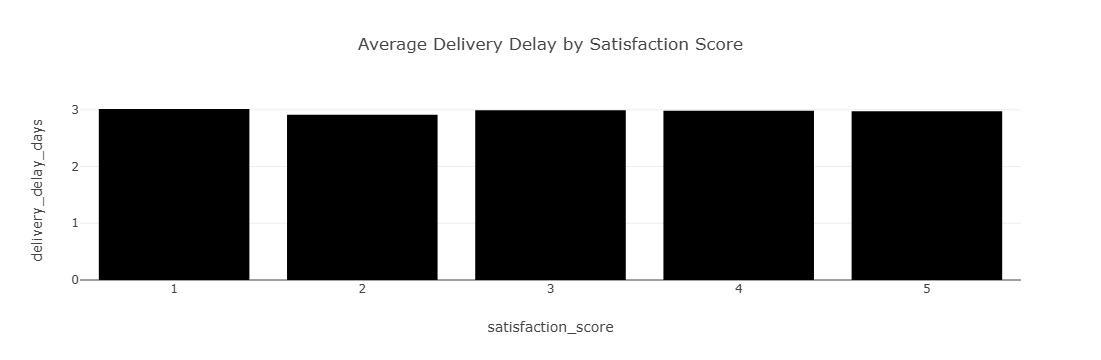

In [76]:
px.bar(
    delay_satisfaction,
    x='satisfaction_score',
    y='delivery_delay_days',
    title='Average Delivery Delay by Satisfaction Score'
)

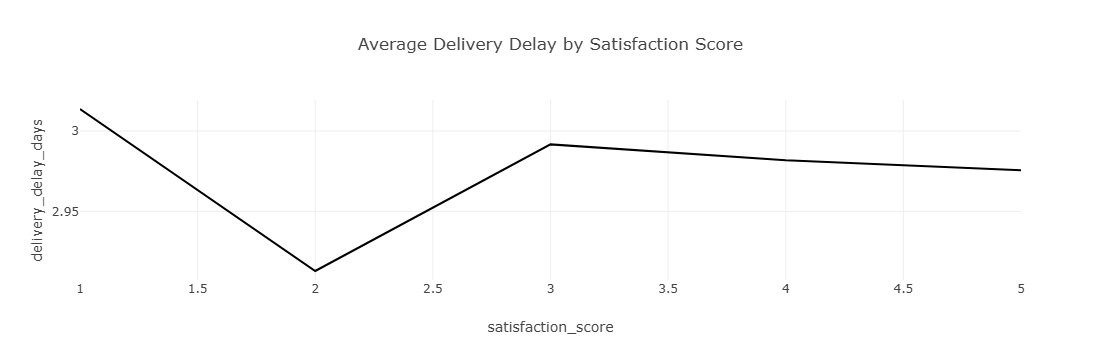

In [77]:
px.line(
    delay_satisfaction,
    x='satisfaction_score',
    y='delivery_delay_days',
    title='Average Delivery Delay by Satisfaction Score'
)

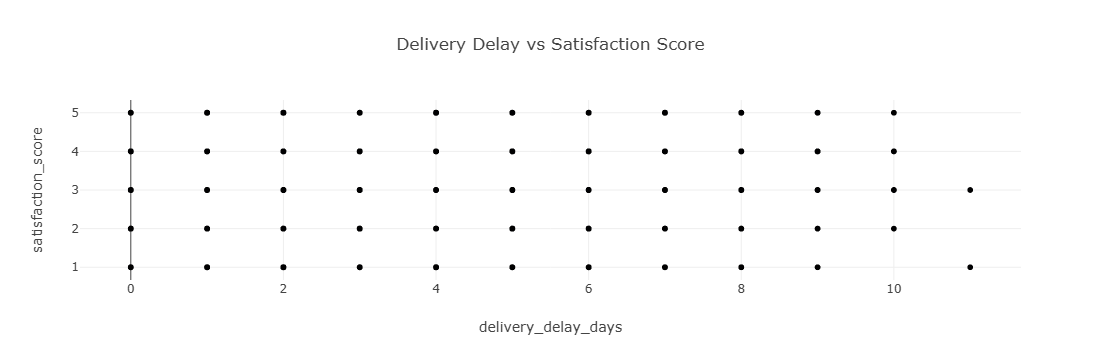

In [78]:
px.scatter(
    df,
    x='delivery_delay_days',
    y='satisfaction_score',
    title='Delivery Delay vs Satisfaction Score'
)

In [79]:
# Categorical Variables 

In [80]:
# Non-Premium Vs Premium

In [81]:
premium_distribution = (
    df['is_premium_user']
    .value_counts()
    .reset_index()
)

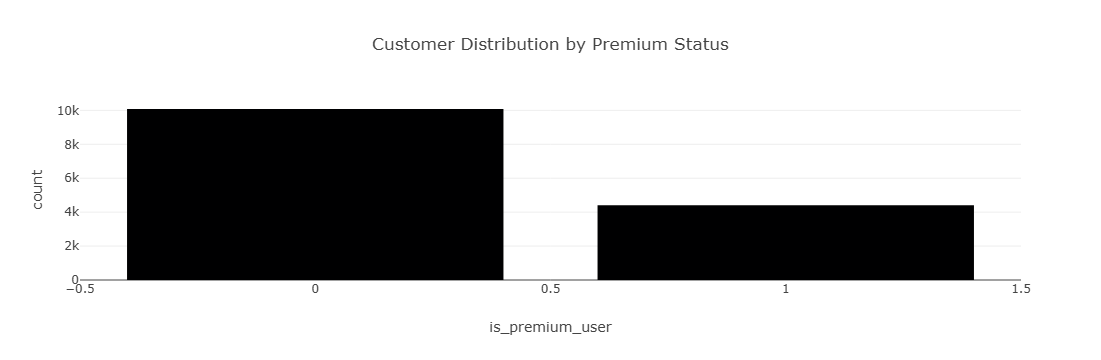

In [82]:
px.bar(
    premium_distribution,
    x='is_premium_user',
    y='count',
    title='Customer Distribution by Premium Status'
)

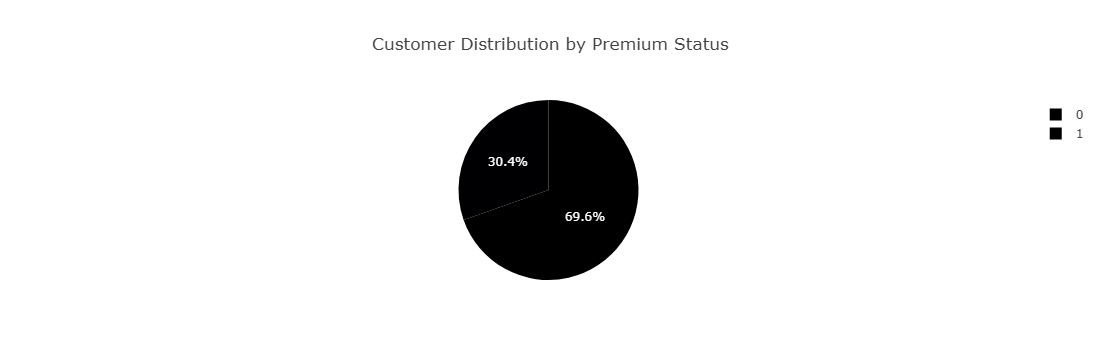

In [83]:
px.pie(
    premium_distribution,
    names='is_premium_user',
    values='count',
    title='Customer Distribution by Premium Status'
)

In [84]:
# discount_used 
# كام عميل استخدم Discount وكام عميل ما استخدمش؟

In [85]:
discount_distribution = (
    df['discount_used']
    .value_counts()
    .reset_index()
)

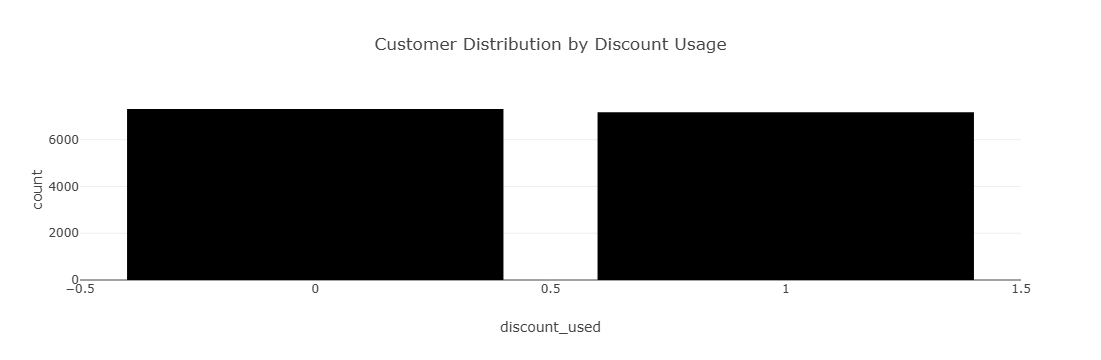

In [86]:
px.bar(
    discount_distribution,
    x='discount_used',
    y='count',
    title='Customer Distribution by Discount Usage'
)

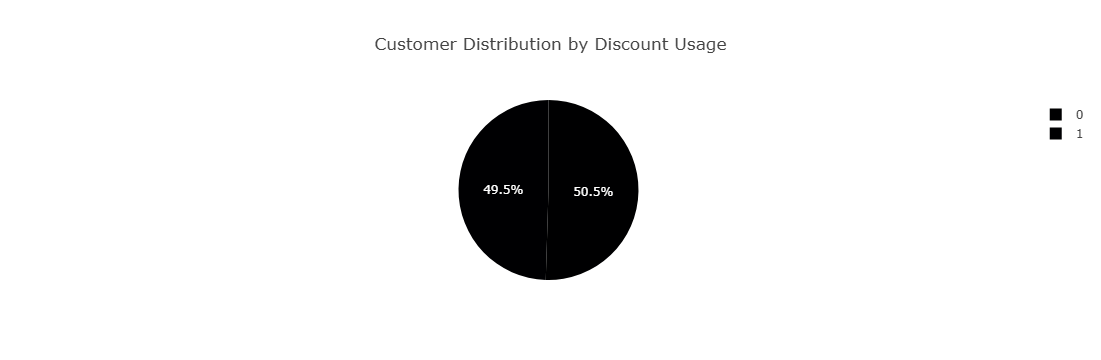

In [87]:
px.pie(
    discount_distribution,
    names='discount_used',
    values='count',
    title='Customer Distribution by Discount Usage'
)

In [88]:
# refund_requested
# كام عميل طلب Refund وكام عميل ما طلبش؟

In [89]:
refund_distribution = (
    df['refund_requested']
    .value_counts()
    .reset_index()
)

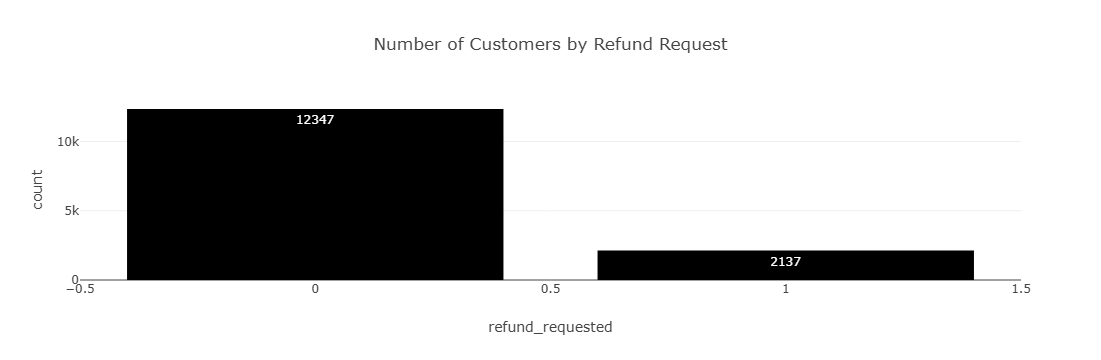

In [90]:
px.bar(
    refund_distribution,
    x='refund_requested',
    y='count',
    title='Number of Customers by Refund Request',
    text='count'
)

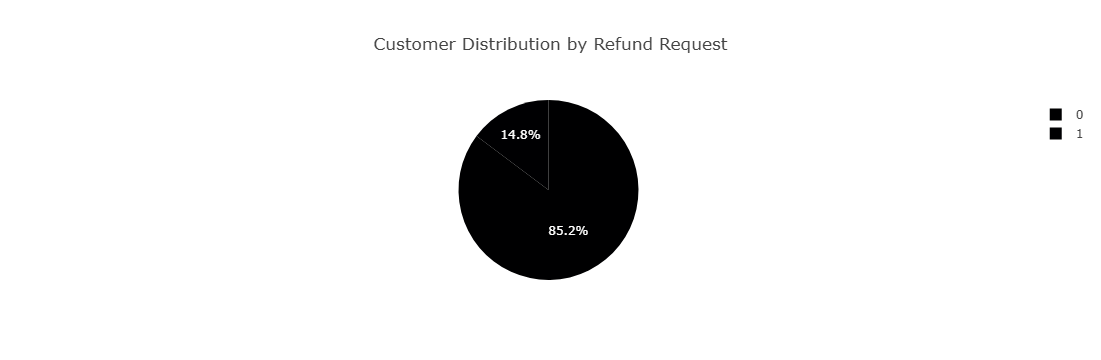

In [91]:
px.pie(
    refund_distribution,
    names='refund_requested',
    values='count',
    title='Customer Distribution by Refund Request'
)

In [92]:
# churn  العملاء اللى توقف تعاملهم معانا 




In [93]:
churn_distribution = (
    df['churn']
    .value_counts()
    .reset_index()
)

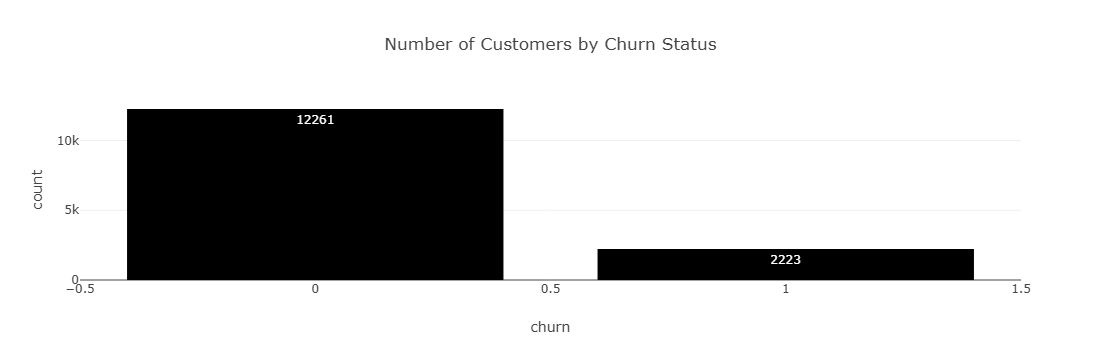

In [94]:
px.bar(
    churn_distribution,
    x='churn',
    y='count',
    title='Number of Customers by Churn Status',
    text='count'
)

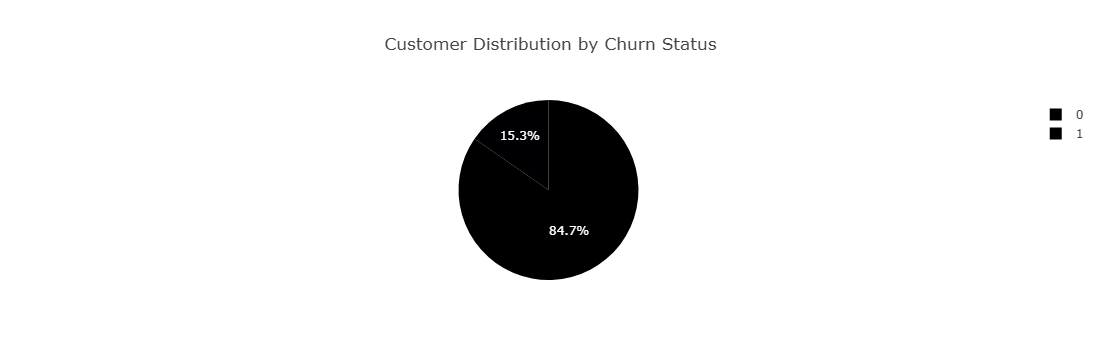

In [95]:
px.pie(
    churn_distribution,
    names='churn',
    values='count',
    title='Customer Distribution by Churn Status'
)

In [96]:
# عدد العملاء حسب is_premium_user و churn

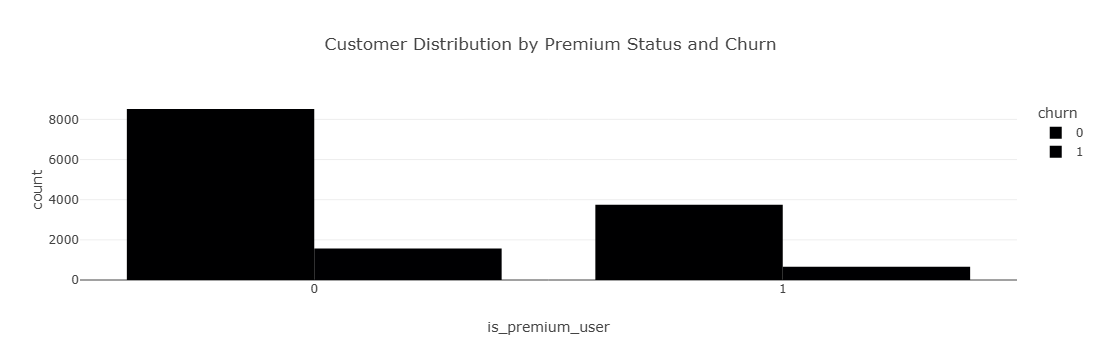

In [97]:
px.histogram(
    df,
    x='is_premium_user',
    color='churn',
    barmode='group',
    title='Customer Distribution by Premium Status and Churn'
)

In [98]:
#discount_used × churn
# هل العملاء اللي استخدموا Discount عندهم Churn مختلف عن اللي ما استخدموش؟

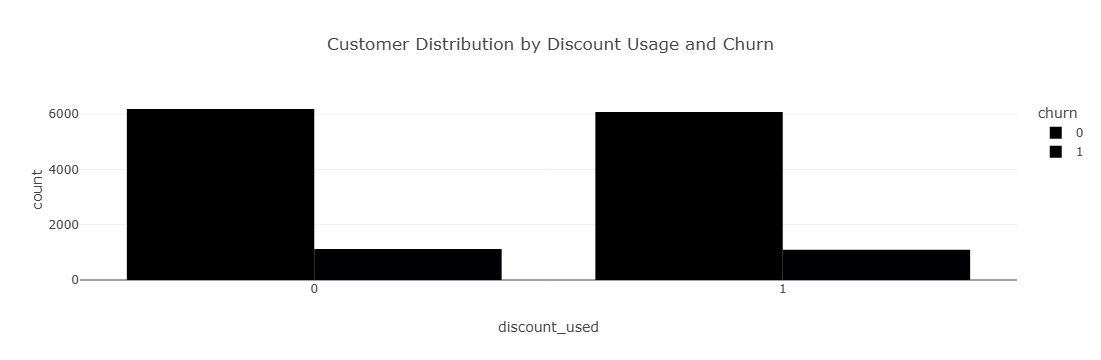

In [99]:
px.histogram(
    df,
    x='discount_used',
    color='churn',
    barmode='group',
    title='Customer Distribution by Discount Usage and Churn'
)

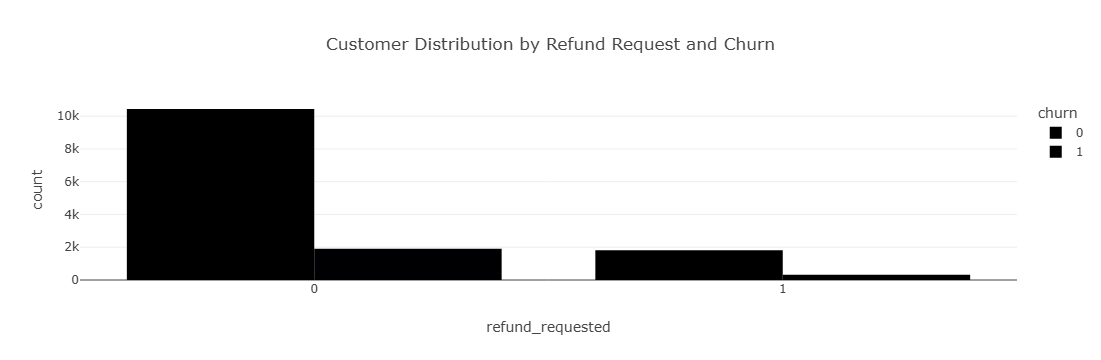

In [100]:
# refund_requested × churn
px.histogram(
    df,
    x='refund_requested',
    color='churn',
    barmode='group',
    title='Customer Distribution by Refund Request and Churn'
)

In [101]:
# gender × churn


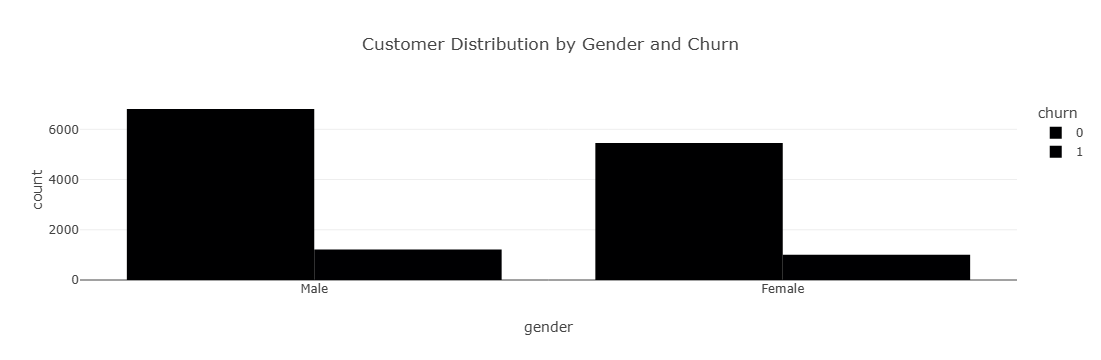

In [102]:
px.histogram(
    df,
    x='gender',
    color='churn',
    barmode='group',
    title='Customer Distribution by Gender and Churn'
)

In [103]:
#payment_method × churn

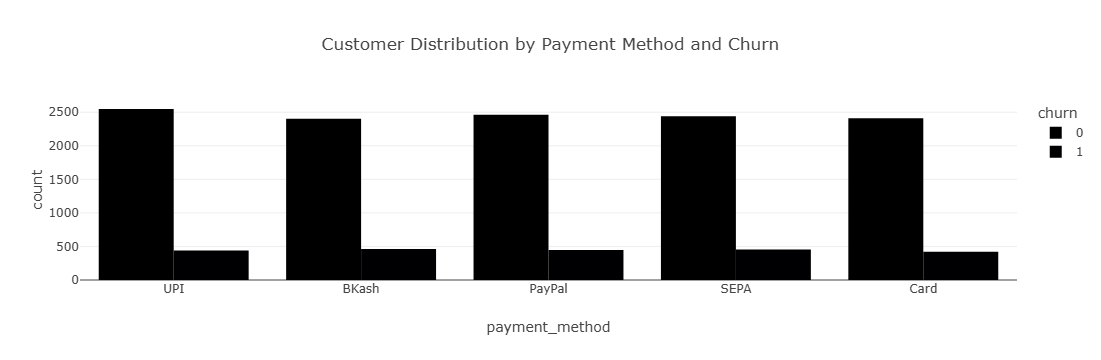

In [104]:
px.histogram(
    df,
    x='payment_method',
    color='churn',
    barmode='group',
    title='Customer Distribution by Payment Method and Churn'
)

In [105]:
# Ordinal × Categorical

In [106]:
# satisfaction_score × churn
# هل متوسط الـ satisfaction_score مختلف بين العملاء اللي عملوا Churn والعملاء المستمرين؟

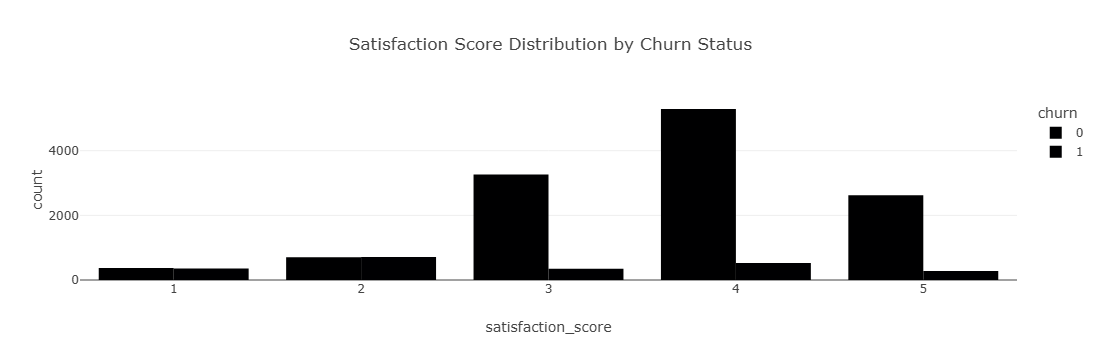

In [107]:
px.histogram(
    df,
    x='satisfaction_score',
    color='churn',
    barmode='group',
    title='Satisfaction Score Distribution by Churn Status'
)

In [108]:
# support_tickets × churn
# هل العملاء اللي عملوا Churn عندهم عدد support_tickets مختلف عن العملاء اللي لسه مستمرين؟

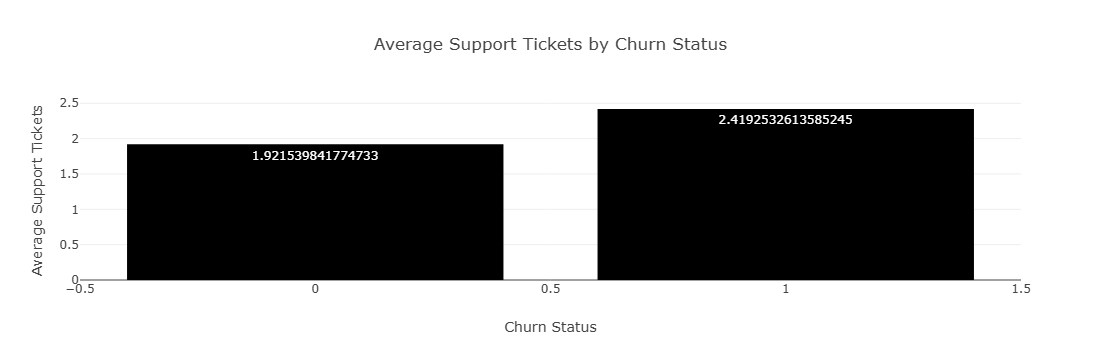

In [109]:
# بما إن support_tickets رقم، وchurn فئتين، هنحسب متوسط عدد الـ tickets لكل حالة Churn:

tickets_churn = (
    df.groupby('churn')['support_tickets']
    .mean()
    .reset_index()
)

fig = px.bar(
    tickets_churn,
    x='churn',
    y='support_tickets',
    title='Average Support Tickets by Churn Status',
    text='support_tickets',
    labels={
        'churn': 'Churn Status',
        'support_tickets': 'Average Support Tickets'
    }
)

fig.show()

In [110]:
# total_spent × churn 
# هل متوسط إنفاق العملاء مختلف بين العملاء اللي عملوا Churn والعملاء المستمرين؟ 

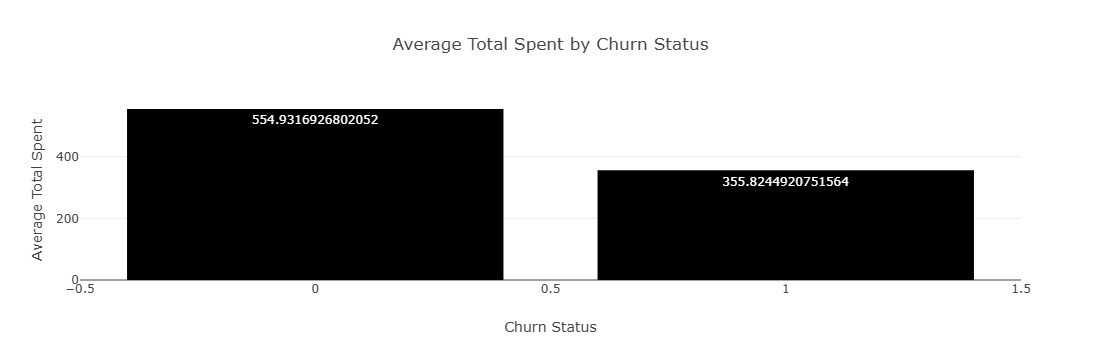

In [111]:
spent_churn = (
    df.groupby('churn')['total_spent']
    .mean()
    .reset_index()
)

fig = px.bar(
    spent_churn,
    x='churn',
    y='total_spent',
    title='Average Total Spent by Churn Status',
    text='total_spent',
    labels={
        'churn': 'Churn Status',
        'total_spent': 'Average Total Spent'
    }
)

fig.show()

In [112]:
# delivery_delay_days × churn


In [113]:
delay_churn = (
    df.groupby('churn')['delivery_delay_days']
    .mean()
    .reset_index()
)

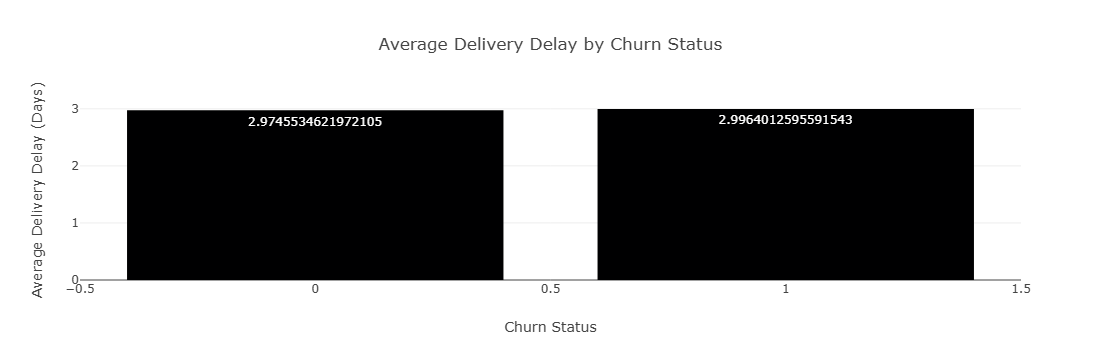

In [114]:
px.bar(
    delay_churn,
    x='churn',
    y='delivery_delay_days',
    title='Average Delivery Delay by Churn Status',
    text='delivery_delay_days',
    labels={
        'churn': 'Churn Status',
        'delivery_delay_days': 'Average Delivery Delay (Days)'
    }
)


In [115]:
# lifetime_value × churn
# هل قيمة العميل على مدار علاقته بالشركة مختلفة بين العملاء المستمرين والعملاء اللي عملوا Churn؟

In [116]:
lifetime_churn = (
    df.groupby('churn')['lifetime_value']
    .mean()
    .reset_index()
)

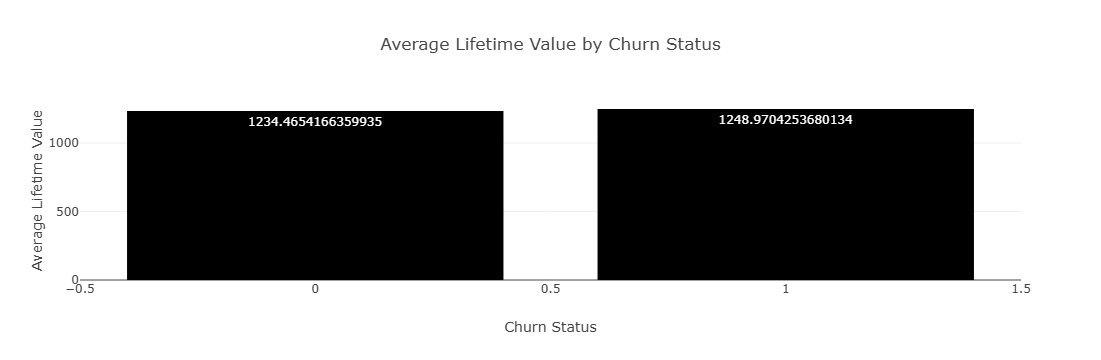

In [117]:
px.bar(
    lifetime_churn,
    x='churn',
    y='lifetime_value',
    title='Average Lifetime Value by Churn Status',
    text='lifetime_value',
    labels={
        'churn': 'Churn Status',
        'lifetime_value': 'Average Lifetime Value'
    }
)

In [118]:
# age × churn

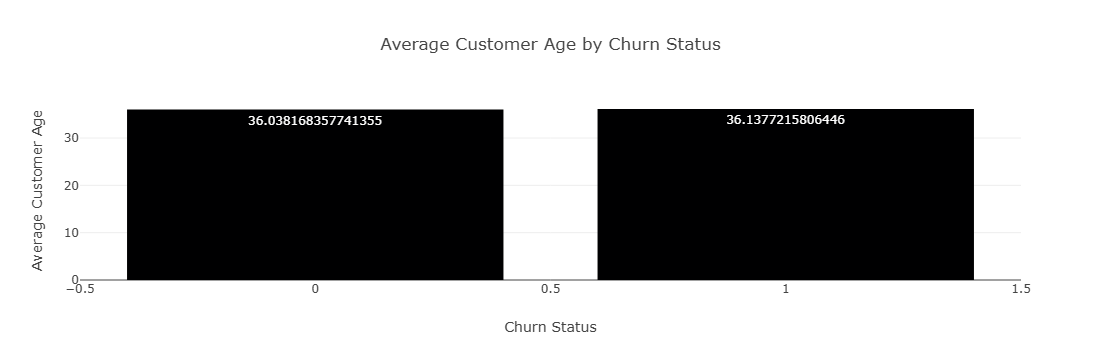

In [119]:
age_churn = (
    df.groupby('churn')['age']
    .mean()
    .reset_index()
)

px.bar(
    age_churn,
    x='churn',
    y='age',
    title='Average Customer Age by Churn Status',
    text='age',
    labels={
        'churn': 'Churn Status',
        'age': 'Average Customer Age'
    }
)

In [120]:
# gender × total_spent
# هنا عايزين نعرف متوسط إجمالي الإنفاق حسب النوع (Gender)

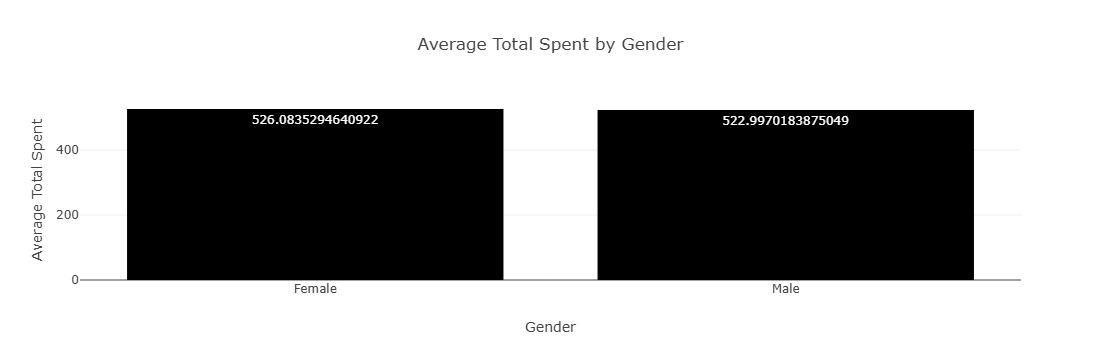

In [121]:
gender_spending = (
    df.groupby('gender')['total_spent']
    .mean()
    .reset_index()
)

px.bar(
    gender_spending,
    x='gender',
    y='total_spent',
    title='Average Total Spent by Gender',
    text='total_spent',
    labels={
        'gender': 'Gender',
        'total_spent': 'Average Total Spent'
    }
)

In [122]:
# payment_method × total_spent 
# عايزين نعرف متوسط إجمالي الإنفاق حسب طريقة الدفع.

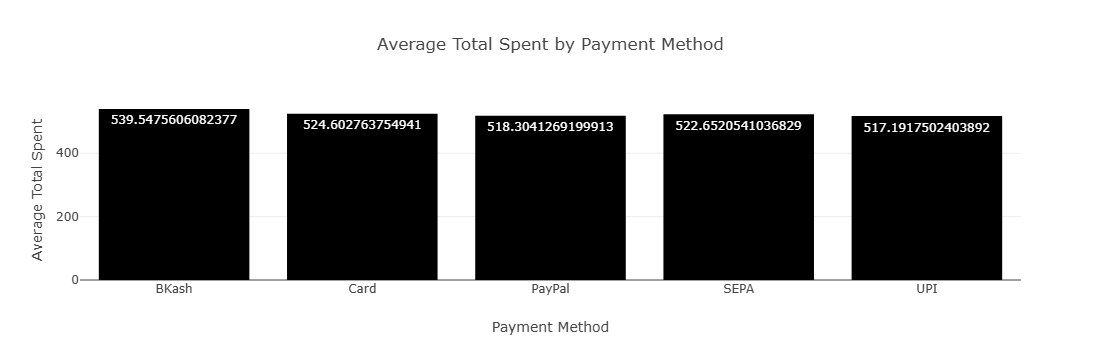

In [123]:
payment_spending = (
    df.groupby('payment_method')['total_spent']
    .mean()
    .reset_index()
)

px.bar(
    payment_spending,
    x='payment_method',
    y='total_spent',
    title='Average Total Spent by Payment Method',
    text='total_spent',
    labels={
        'payment_method': 'Payment Method',
        'total_spent': 'Average Total Spent'
    }
)

In [130]:
df.to_csv('Sales_Marketing_cleaned.csv', index=False)

In [125]:
import os 
os.getcwd()

'C:\\Users\\Dell'

In [126]:
os.chdir(r'C:\Users\Dell\OneDrive\Desktop\George project')

In [127]:
os.getcwd()

'C:\\Users\\Dell\\OneDrive\\Desktop\\George project'

In [131]:
%%writefile Sales_Marketing_cleaned.py
import streamlit as st
import pandas as pd
import plotly.express as px

# ---------------------------------------------------------
# 1. Page Configuration & Data Setup
# ---------------------------------------------------------
st.set_page_config(
    page_title="Executive Sales & Marketing Dashboard",
    layout="wide"
)

df = pd.read_csv("Sales_Marketing_cleaned.csv")

# ---------------------------------------------------------
# Data Cleaning & Human-Readable Mapping (0/1 -> Descriptive Text)
# ---------------------------------------------------------
if 'churn' in df.columns:
    df['churn_label'] = df['churn'].map({0: 'Active Customer', 1: 'Churned Customer'})
if 'is_premium_user' in df.columns:
    df['premium_label'] = df['is_premium_user'].map({0: 'Standard User', 1: 'Premium User'})
if 'discount_used' in df.columns:
    df['discount_label'] = df['discount_used'].map({0: 'No Discount', 1: 'Discount Applied'})
if 'refund_requested' in df.columns:
    df['refund_label'] = df['refund_requested'].map({0: 'No Refund', 1: 'Refund Requested'})

# ---------------------------------------------------------
# 2. Sidebar Navigation (Business-Oriented Category Names)
# ---------------------------------------------------------
st.sidebar.title("Navigation & Filters")

main_page = st.sidebar.selectbox(
    'Select Dashboard Section:',
    [
        '1. Executive Summary & Core KPIs',
        '2. Customer Engagement & Financials',
        '3. Retention, Churn & Demographics',
        '4. Payment Gateways & Spending Trends',
        '5. Customer Satisfaction & Support Impact'
    ]
)

st.sidebar.markdown("---")

sub_page = None

if main_page == '1. Executive Summary & Core KPIs':
    sub_page = st.sidebar.radio('Select View:', ['Key Metrics Overview', 'Demographic Distributions'])

elif main_page == '2. Customer Engagement & Financials':
    sub_page = st.sidebar.radio('Select View:', ['Website Visits vs Total Spent', 'Tenure Days vs Lifetime Value', 'Acquisition Channel ROI'])

elif main_page == '3. Retention, Churn & Demographics':
    sub_page = st.sidebar.radio('Select View:', ['Gender & Country Churn Analysis', 'Subscription Plans & Payment Methods', 'Discounts & Refund Impact on Churn'])

elif main_page == '4. Payment Gateways & Spending Trends':
    sub_page = st.sidebar.radio('Select View:', ['Spending by Gender & Payment Method', 'Support Tickets & Delivery Delays by Churn Status'])

elif main_page == '5. Customer Satisfaction & Support Impact':
    sub_page = st.sidebar.radio('Select View:', ['Satisfaction Score Breakdown', 'Satisfaction vs Support Tickets'])

st.sidebar.markdown("---")
st.sidebar.subheader("Global Data Filters")

countries = ["All"] + list(df['country'].dropna().unique()) if 'country' in df.columns else ["All"]
selected_country = st.sidebar.selectbox("Country:", countries)

sub_types = ["All"] + list(df['subscription_type'].dropna().unique()) if 'subscription_type' in df.columns else ["All"]
selected_sub = st.sidebar.selectbox("Subscription Type:", sub_types)

if selected_country != "All":
    df = df[df['country'] == selected_country]
if selected_sub != "All":
    df = df[df['subscription_type'] == selected_sub]


# =========================================================
# SECTION 1: Executive Summary & Core KPIs
# =========================================================
if main_page == '1. Executive Summary & Core KPIs':
    st.title('Executive Summary & Core KPIs')
    
    col1, col2, col3, col4 = st.columns(4)
    with col1:
        st.metric("Total Revenue", f"${df['total_spent'].sum():,.0f}")
    with col2:
        st.metric("Avg Lifetime Value (LTV)", f"${df['lifetime_value'].mean():,.1f}")
    with col3:
        churn_rate = (df['churn'].mean() * 100) if 'churn' in df.columns else 0
        st.metric("Overall Churn Rate", f"{churn_rate:.1f}%")
    with col4:
        st.metric("Avg Satisfaction Score", f"{df['satisfaction_score'].mean():,.2f} / 5")

    st.markdown("---")

    if sub_page == 'Key Metrics Overview':
        st.info("Use the sidebar options to explore customer behavior and financial metrics.")
        c1, c2 = st.columns(2)
        with c1:
            prem_spend = df.groupby('premium_label')['total_spent'].mean().reset_index()
            fig_prem = px.bar(
                prem_spend, x='premium_label', y='total_spent', text_auto='.2f',
                title='Average Spending by Premium Status',
                color='premium_label', template="plotly_white",
                labels={'premium_label': 'User Tier', 'total_spent': 'Avg Total Spent ($)'}
            )
            st.plotly_chart(fig_prem, use_container_width=True)
            
        with c2:
            age_spend = df.groupby('age')['total_spent'].mean().reset_index()
            fig_age = px.line(
                age_spend, x='age', y='total_spent',
                title='Average Spending Trend by Customer Age',
                labels={'age': 'Customer Age', 'total_spent': 'Avg Total Spent ($)'},
                template="plotly_white"
            )
            st.plotly_chart(fig_age, use_container_width=True)

    elif sub_page == 'Demographic Distributions':
        fig_demo = px.histogram(
            df, x='age', color='premium_label', barmode='group',
            title='Customer Age Distribution by Premium Status',
            labels={'age': 'Customer Age', 'premium_label': 'User Tier'},
            template="plotly_white"
        )
        st.plotly_chart(fig_demo, use_container_width=True)


# =========================================================
# SECTION 2: Customer Engagement & Financials
# =========================================================
elif main_page == '2. Customer Engagement & Financials':
    st.title('Customer Engagement & Financial Analysis')

    if sub_page == "Website Visits vs Total Spent":
        col1, col2 = st.columns(2)
        with col1:
            df['visits_group'] = pd.cut(df['total_visits'], bins=4, labels=['1-8 Visits', '9-16 Visits', '17-24 Visits', '25+ Visits'])
            visits_spend = df.groupby(['visits_group', 'churn_label'], observed=False)['total_spent'].mean().reset_index()
            
            fig_bar_visits = px.bar(
                visits_spend, x='visits_group', y='total_spent', color='churn_label',
                barmode='group', text_auto='.1f',
                title='Average Spent ($) by Visit Groups & Retention Status',
                labels={'visits_group': 'Visits Category', 'total_spent': 'Avg Total Spent ($)', 'churn_label': 'Customer Status'},
                template="plotly_white"
            )
            st.plotly_chart(fig_bar_visits, use_container_width=True)
            
        with col2:
            visits_spending = df.groupby('total_visits')['total_spent'].mean().reset_index()
            fig_line1 = px.line(
                visits_spending, x='total_visits', y='total_spent',
                title='Average Total Spent Trend by Exact Visit Count',
                labels={'total_visits': 'Total Visits', 'total_spent': 'Avg Total Spent ($)'},
                template="plotly_white"
            )
            st.plotly_chart(fig_line1, use_container_width=True)

    elif sub_page == "Tenure Days vs Lifetime Value":
        df['tenure_bins'] = pd.cut(df['customer_tenure_days'], bins=4, labels=['New (<3 Months)', 'Established (3-6 Months)', 'Loyal (6-12 Months)', 'VIP (12+ Months)'])
        tenure_ltv = df.groupby(['tenure_bins', 'churn_label'], observed=False)['lifetime_value'].mean().reset_index()
        
        fig_tenure_ltv = px.bar(
            tenure_ltv, x='tenure_bins', y='lifetime_value', color='churn_label',
            barmode='group', text_auto='.1f',
            title='Average Lifetime Value (LTV) by Tenure Groups & Status',
            labels={'tenure_bins': 'Tenure Group', 'lifetime_value': 'Avg LTV ($)', 'churn_label': 'Customer Status'},
            template="plotly_white"
        )
        st.plotly_chart(fig_tenure_ltv, use_container_width=True)

    elif sub_page == "Acquisition Channel ROI":
        mkt_roi = df.groupby('acquisition_channel')[['marketing_spend_per_user', 'lifetime_value']].mean().reset_index()
        fig_roi = px.bar(
            mkt_roi, x='acquisition_channel', y=['marketing_spend_per_user', 'lifetime_value'],
            barmode='group', text_auto='.1f',
            title='Marketing Spend per User vs Lifetime Value (LTV) by Channel',
            labels={'acquisition_channel': 'Acquisition Channel', 'value': 'Amount ($)', 'variable': 'Metric'},
            template="plotly_white"
        )
        st.plotly_chart(fig_roi, use_container_width=True)


# =========================================================
# SECTION 3: Retention, Churn & Demographics
# =========================================================
elif main_page == '3. Retention, Churn & Demographics':
    st.title('Retention, Churn & Demographic Breakdown')

    if sub_page == "Gender & Country Churn Analysis":
        col1, col2 = st.columns(2)
        with col1:
            gender_churn = df.groupby(['gender', 'churn_label']).size().reset_index(name='count')
            fig_g_churn = px.bar(
                gender_churn, x='gender', y='count', color='churn_label',
                barmode='group', text_auto=True,
                title='Customer Retention Count by Gender',
                labels={'gender': 'Gender', 'count': 'Customer Count', 'churn_label': 'Customer Status'},
                template="plotly_white"
            )
            st.plotly_chart(fig_g_churn, use_container_width=True)

        with col2:
            country_churn = df.groupby(['country', 'churn_label']).size().reset_index(name='count')
            fig_c_churn = px.bar(
                country_churn, x='country', y='count', color='churn_label',
                barmode='group', text_auto=True,
                title='Customer Retention Status by Country',
                labels={'country': 'Country', 'count': 'Customer Count', 'churn_label': 'Customer Status'},
                template="plotly_white"
            )
            st.plotly_chart(fig_c_churn, use_container_width=True)

    elif sub_page == "Subscription Plans & Payment Methods":
        fig_sub_pay = px.histogram(
            df, x='payment_method', color='subscription_type', barmode='group',
            text_auto=True, title='Subscription Plan Distribution Across Payment Gateways',
            labels={'payment_method': 'Payment Method', 'subscription_type': 'Subscription Type'},
            template="plotly_white"
        )
        st.plotly_chart(fig_sub_pay, use_container_width=True)

    elif sub_page == "Discounts & Refund Impact on Churn":
        col1, col2 = st.columns(2)
        with col1:
            disc_churn = df.groupby(['discount_label', 'churn_label']).size().reset_index(name='count')
            fig_disc = px.bar(
                disc_churn, x='discount_label', y='count', color='churn_label',
                barmode='group', text_auto=True,
                title='Discount Usage Impact on Retention',
                labels={'discount_label': 'Discount Status', 'count': 'Customer Count', 'churn_label': 'Customer Status'},
                template="plotly_white"
            )
            st.plotly_chart(fig_disc, use_container_width=True)

        with col2:
            ref_churn = df.groupby(['refund_label', 'churn_label']).size().reset_index(name='count')
            fig_ref = px.bar(
                ref_churn, x='refund_label', y='count', color='churn_label',
                barmode='group', text_auto=True,
                title='Refund Request Impact on Retention',
                labels={'refund_label': 'Refund Status', 'count': 'Customer Count', 'churn_label': 'Customer Status'},
                template="plotly_white"
            )
            st.plotly_chart(fig_ref, use_container_width=True)


# =========================================================
# SECTION 4: Payment Gateways & Spending Trends
# =========================================================
elif main_page == '4. Payment Gateways & Spending Trends':
    st.title('Payment Gateways & Spending Analysis')

    if sub_page == "Spending by Gender & Payment Method":
        col1, col2 = st.columns(2)
        with col1:
            gender_spending = df.groupby('gender')['total_spent'].mean().reset_index()
            fig_g_spend = px.bar(
                gender_spending, x='gender', y='total_spent', text_auto='.2f',
                title='Average Total Spent ($) by Gender',
                labels={'gender': 'Gender', 'total_spent': 'Avg Total Spent ($)'},
                template="plotly_white"
            )
            st.plotly_chart(fig_g_spend, use_container_width=True)

        with col2:
            pay_spend = df.groupby('payment_method')['total_spent'].mean().reset_index()
            fig_p_spent = px.bar(
                pay_spend, x='payment_method', y='total_spent', text_auto='.2f',
                title='Average Total Spent ($) by Payment Gateway',
                labels={'payment_method': 'Payment Gateway', 'total_spent': 'Avg Total Spent ($)'},
                template="plotly_white"
            )
            st.plotly_chart(fig_p_spent, use_container_width=True)

    elif sub_page == "Support Tickets & Delivery Delays by Churn Status":
        col1, col2 = st.columns(2)
        with col1:
            tickets_churn = df.groupby('churn_label')['support_tickets'].mean().reset_index()
            fig_t = px.bar(
                tickets_churn, x='churn_label', y='support_tickets', text_auto='.2f',
                title='Average Support Tickets Count by Churn Status',
                labels={'churn_label': 'Customer Status', 'support_tickets': 'Avg Support Tickets'},
                template="plotly_white"
            )
            st.plotly_chart(fig_t, use_container_width=True)

        with col2:
            delay_churn = df.groupby('churn_label')['delivery_delay_days'].mean().reset_index()
            fig_d = px.bar(
                delay_churn, x='churn_label', y='delivery_delay_days', text_auto='.2f',
                title='Average Delivery Delay (Days) by Churn Status',
                labels={'churn_label': 'Customer Status', 'delivery_delay_days': 'Avg Delay (Days)'},
                template="plotly_white"
            )
            st.plotly_chart(fig_d, use_container_width=True)


# =========================================================
# SECTION 5: Customer Satisfaction & Support Impact
# =========================================================
elif main_page == '5. Customer Satisfaction & Support Impact':
    st.title('Customer Satisfaction & Support Impact')

    if sub_page == "Satisfaction Score Breakdown":
        col1, col2 = st.columns(2)
        with col1:
            fig_sat_c = px.histogram(
                df, x='satisfaction_score', color='churn_label', barmode='group',
                text_auto=True, title='Satisfaction Score Distribution (1-5) by Retention Status',
                labels={'satisfaction_score': 'Satisfaction Score (1 to 5)', 'churn_label': 'Customer Status'},
                template="plotly_white"
            )
            st.plotly_chart(fig_sat_c, use_container_width=True)

        with col2:
            delay_satisfaction = df.groupby('satisfaction_score')['delivery_delay_days'].mean().reset_index()
            fig_sat_d = px.line(
                delay_satisfaction, x='satisfaction_score', y='delivery_delay_days',
                title='Average Delivery Delay Days by Satisfaction Score',
                labels={'satisfaction_score': 'Satisfaction Score (1 to 5)', 'delivery_delay_days': 'Avg Delay Days'},
                template="plotly_white"
            )
            st.plotly_chart(fig_sat_d, use_container_width=True)

    elif sub_page == "Satisfaction vs Support Tickets":
        sat_tickets = df.groupby(['support_tickets', 'churn_label'])['satisfaction_score'].mean().reset_index()
        fig_bar_sat = px.bar(
            sat_tickets, x='support_tickets', y='satisfaction_score', color='churn_label',
            barmode='group', text_auto='.2f',
            title='Average Satisfaction Score by Support Ticket Count & Status',
            labels={'support_tickets': 'Number of Support Tickets', 'satisfaction_score': 'Avg Satisfaction Score (1-5)', 'churn_label': 'Customer Status'},
            template="plotly_white"
        )
        st.plotly_chart(fig_bar_sat, use_container_width=True)

Overwriting Sales_Marketing_cleaned.py


In [132]:
! streamlit run Sales_Marketing_cleaned.py

^C
